## **XGBoost Notebook**

This notebook serves as a tutorial / testing ground where I can add new variables for testing on a small scale, before putting into my script. It's slightly different compared to the script, in which the script uses entire datasets for training, and then gets tested on unseen datasets, whereas this notebook takes 1 (sometimes more) datasets, and splits the sets randomly 80/20. This may be moved to the way the script works, as its easier to plot how well train vs test is, which is good for noticing overfitting.

In [7]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import uproot
import awkward as ak 
import vector

In [8]:
input_files_18x275 = [
    "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2276.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2275.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2274.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2273.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2272.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2271.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2270.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2269.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2268.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2267.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2266.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2265.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2264.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2263.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2262.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2261.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2260.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2259.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2258.eicrecon.edm4eic.root",
    # "/home/user321/pythia8NCDIS_18x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.2257.eicrecon.edm4eic.root",
 ]

input_files_5x41 = [
    "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0830.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0831.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0832.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0833.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0834.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0835.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0836.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0837.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0838.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0839.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0840.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0841.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0842.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0843.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0844.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0845.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0846.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0847.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0848.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/5x41/minQ2=1/pythia8NCDIS_5x41_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.0849.eicrecon.edm4eic.root",
]

input_files_10x275 = [
    "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1971.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1970.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1969.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1968.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1967.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1966.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1965.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1964.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1963.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1962.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1961.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1960.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1959.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1958.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1957.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1956.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1955.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1954.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1953.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_5.1952.eicrecon.edm4eic.root"
]

trees = [uproot.open(f)["events"] for f in input_files_10x275]

In [9]:
filter_name=[
    "ReconstructedChargedParticles/ReconstructedChargedParticles.*",
    #"ReconstructedChargedParticles/ReconstructedChargedParticles.*",
    "MCParticles/MCParticles.*",
    "EcalBarrelClusters/EcalBarrelClusters.*",
    "EcalEndcapPClusters/EcalEndcapPClusters.*",
    "EcalEndcapNClusters/EcalEndcapNClusters.*",
    "EcalBarrelClusterAssociations/EcalBarrelClusterAssociations.*",
    "EcalEndcapPClusterAssociations/EcalEndcapPClusterAssociations.*",
    "EcalEndcapNClusterAssociations/EcalEndcapNClusterAssociations.*",
    "ReconstructedChargedParticleAssociations/ReconstructedChargedParticleAssociations.*",
    #"ReconstructedChargedParticleAssociations/ReconstructedChargedParticleAssociations.*",
    "InclusiveKinematicsTruth/InclusiveKinematicsTruth.*",
]

events_list = [tree.arrays(filter_name=filter_name, library="ak") for tree in trees]
events = ak.concatenate(events_list, axis=0)

### **Boosting**

Here, the entire boost from lorentzboost.py isn't used. This is because its not useful here as $Q^{2}$, $x$ and $y$ aren't computed here. Instead, the beam angle crossing correction is applied and that's all for now. I assume the Bjorken values aren't good for discriminating as they're representative of the event rather than the scattered electron (i think), but will remember to ask.



In [10]:
# boosting using vector
crossing_angle = -0.025 # radians
mass = 0.000511 

def determine_boost(beam_E_electron, beam_E_proton, crossing_angle = -0.025):
    beam_electron = vector.obj(px = 0, py = 0, pz = -beam_E_electron, E = beam_E_electron)
    beam_proton = vector.obj(px = beam_E_proton * np.sin(crossing_angle), py = 0, pz = beam_E_proton * np.cos(crossing_angle), E = beam_E_proton)

    P_tot = beam_electron + beam_proton
    p_p_cm = beam_proton.boostCM_of_p4(P_tot)

    rot_y_angle = -1.0 * np.arctan2(p_p_cm.px, p_p_cm.pz)
    p_p_cm_rotY = p_p_cm.rotateY(rot_y_angle)

    rot_x_angle = np.arctan2(p_p_cm_rotY.py, p_p_cm_rotY.pz)
    p_p_cm_rotYX = p_p_cm_rotY.rotateX(rot_x_angle)
    
    return P_tot, rot_y_angle, rot_x_angle

def apply_boost(px, py, pz, E=None, P_tot=None, rot_y_angle=None, rot_x_angle=None, mass = 0.000511):
    if E is None:
        E = np.sqrt(px**2 + py**2 + pz**2 + mass**2)

    if P_tot is None or rot_y_angle is None or rot_x_angle is None:
        P_tot, rot_y_angle, rot_x_angle = determine_boost(beam_E_electron, beam_E_proton, crossing_angle)

    particle = vector.Array(ak.zip({
        "px": px,
        "py": py,
        "pz": pz,
        "E": E
    }))
    boosted_particle = particle.boostCM_of_p4(P_tot).rotateY(rot_y_angle).rotateX(rot_x_angle)
    return boosted_particle.px, boosted_particle.py, boosted_particle.pz, boosted_particle.E

P_tot, rot_y_angle, rot_x_angle = determine_boost(10, 275, -0.025)

In [11]:
# defining variables

# mc classification
mc_pdg = events["MCParticles.PDG"]
mc_gen = events["MCParticles.generatorStatus"]


# track kinematics (raw from detector)
px_raw = events["ReconstructedChargedParticles.momentum.x"]
py_raw = events["ReconstructedChargedParticles.momentum.y"]
pz_raw = events["ReconstructedChargedParticles.momentum.z"]
charge = events["ReconstructedChargedParticles.charge"]

# charged track kinematics (C++-style E/p uses these)
# ch_px_raw = events["ReconstructedChargedParticles.momentum.x"]
# ch_py_raw = events["ReconstructedChargedParticles.momentum.y"]
# ch_pz_raw = events["ReconstructedChargedParticles.momentum.z"]
# ch_charge = events["ReconstructedChargedParticles.charge"]
 
# boosting for event-level variables
massless_E = np.sqrt(px_raw**2 + py_raw**2 + pz_raw**2)

# massless_E_ch = np.sqrt(ch_px_raw**2 + ch_py_raw**2 + ch_pz_raw**2)

# cluster energies
barrel_E = events["EcalBarrelClusters.energy"]
endcapP_E = events["EcalEndcapPClusters.energy"]
endcapN_E = events["EcalEndcapNClusters.energy"]

# calorimeter cluster positions (Cartesian, in mm)
barrel_pos_x  = events["EcalBarrelClusters.position.x"]
barrel_pos_y  = events["EcalBarrelClusters.position.y"]
barrel_pos_z  = events["EcalBarrelClusters.position.z"]
endcapP_pos_x = events["EcalEndcapPClusters.position.x"]
endcapP_pos_y = events["EcalEndcapPClusters.position.y"]
endcapP_pos_z = events["EcalEndcapPClusters.position.z"]
endcapN_pos_x = events["EcalEndcapNClusters.position.x"]
endcapN_pos_y = events["EcalEndcapNClusters.position.y"]
endcapN_pos_z = events["EcalEndcapNClusters.position.z"]

vector.register_awkward() # vector used instead of PxPyPzEVector for compatibility
reco_vec = vector.Array(ak.zip({   # zip takes the awkward arrays and makes a single structured array where each element   
    "px": px_raw,                  # has a named field
    "py": py_raw,
    "pz": pz_raw,
    "energy": np.sqrt(px_raw**2 + py_raw**2 + pz_raw**2 + mass**2)  # massless for now, won't even be used
}))

pt = reco_vec.pt  # transverse momentum 
eta = reco_vec.eta # pseudorapidity
phi = reco_vec.phi # azimuthal angle
p = np.sqrt(px_raw**2 + py_raw**2 + pz_raw**2) # momentum magnitude

# charged track 4-vector and kinematic variables
# ch_reco_vec = vector.Array(ak.zip({
#     "px": ch_px_raw,
#     "py": ch_py_raw,
#     "pz": ch_pz_raw,
#     "energy": np.sqrt(ch_px_raw**2 + ch_py_raw**2 + ch_pz_raw**2 + mass**2)
# }))

# ch_pt = ch_reco_vec.pt
# ch_eta = ch_reco_vec.eta
# ch_phi = ch_reco_vec.phi
# p_ch = np.sqrt(ch_px_raw**2 + ch_py_raw**2 + ch_pz_raw**2) # momentum magnitude

# mc matching, same logic as my C++ cluster reconstruction code
# ReconstructedParticle and MC associations
reco_to_mc_rec = events["ReconstructedChargedParticleAssociations.recID"]  # reco particle index
reco_to_mc_sim = events["ReconstructedChargedParticleAssociations.simID"]  # MC particle index

# charged track associations
# reco_to_mc_rec_ch = events["ReconstructedChargedParticleAssociations.recID"]
# reco_to_mc_sim_ch = events["ReconstructedChargedParticleAssociations.simID"]

# cluster and MC associations (recID is cluster index, simID is MC particle index)
barrel_clu_idx  = events["EcalBarrelClusterAssociations.recID"]
barrel_mc_idx = events["EcalBarrelClusterAssociations.simID"]

endcapN_clu_idx = events["EcalEndcapNClusterAssociations.recID"]
endcapN_mc_idx = events["EcalEndcapNClusterAssociations.simID"]

# same for the endcaps
endcapP_clu_idx = events["EcalEndcapPClusterAssociations.recID"]
endcapP_mc_idx = events["EcalEndcapPClusterAssociations.simID"]

# boosted variables
boosted_px, boosted_py, boosted_pz, boosted_E = apply_boost(px_raw, py_raw, pz_raw, massless_E, P_tot, rot_y_angle, rot_x_angle)
# boosted_px_ch, boosted_py_ch, boosted_pz_ch, boosted_E_ch = apply_boost(ch_px_raw, ch_py_raw, ch_pz_raw, massless_E_ch, P_tot, rot_y_angle, rot_x_angle)

In [12]:
# defining event level variables

trueQ2 = events["InclusiveKinematicsTruth.Q2"]
truex = events["InclusiveKinematicsTruth.x"]
truey = events["InclusiveKinematicsTruth.y"]

### **Matching**

Code is meant to follow same workflow as that in the C++ code from sem1. Uses the MC particles as an intermediary to match reco particles and cluster energies. Was initially designed just for energies, but works generally for the phi and eta calculation used in the isolation section.

In [13]:
# matching - vectorised version
def match_via_mc_vectorised(reco_rec, reco_sim,
                            barrel_clu, barrel_mc, barrel_val,
                            endcapP_clu, endcapP_mc, endcapP_val,
                            endcapN_clu, endcapN_mc, endcapN_val, n_reco):
    barrel_out  = np.zeros(n_reco, dtype=np.float64)
    endcapN_out = np.zeros(n_reco, dtype=np.float64)
    endcapP_out = np.zeros(n_reco, dtype=np.float64)

    # build mc→reco lookup (numpy arrays, no Python dict)
    reco_rec_np = np.asarray(reco_rec, dtype=np.intp)
    reco_sim_np = np.asarray(reco_sim, dtype=np.intp)

    if len(reco_sim_np) == 0:
        return barrel_out, endcapN_out, endcapP_out

    max_mc = max(reco_sim_np.max(),
                 int(ak.max(barrel_mc))  if len(barrel_mc)  > 0 else 0,
                 int(ak.max(endcapP_mc)) if len(endcapP_mc) > 0 else 0,
                 int(ak.max(endcapN_mc)) if len(endcapN_mc) > 0 else 0) + 1

    mc_to_reco = np.full(max_mc, -1, dtype=np.intp)
    mc_to_reco[reco_sim_np] = reco_rec_np

    for clu_idx_arr, mc_idx_arr, val_arr, out_arr in [
        (barrel_clu,  barrel_mc,  barrel_val,  barrel_out),
        (endcapN_clu, endcapN_mc, endcapN_val, endcapN_out),
        (endcapP_clu, endcapP_mc, endcapP_val, endcapP_out),
    ]:
        if len(mc_idx_arr) == 0:
            continue
        mc_np  = np.asarray(mc_idx_arr, dtype=np.intp)
        clu_np = np.asarray(clu_idx_arr, dtype=np.intp)
        reco_targets = mc_to_reco[mc_np]
        valid = reco_targets >= 0
        out_arr[reco_targets[valid]] = np.asarray(val_arr)[clu_np[valid]]

    return barrel_out, endcapN_out, endcapP_out

In [14]:
# results using vectorised version
results_vectorised = [
    match_via_mc_vectorised(r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco)
    for r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco in zip(
        reco_to_mc_rec, reco_to_mc_sim,
        barrel_clu_idx, barrel_mc_idx, barrel_E,
        endcapP_clu_idx, endcapP_mc_idx, endcapP_E,
        endcapN_clu_idx, endcapN_mc_idx, endcapN_E,
        ak.num(px_raw))]

barrel_E_per_reco_vec = ak.Array([r[0] for r in results_vectorised])
endcapN_E_per_reco_vec = ak.Array([r[1] for r in results_vectorised])
endcapP_E_per_reco_vec = ak.Array([r[2] for r in results_vectorised])

matched_calo_E_vec = ak.where(
    barrel_E_per_reco_vec > 0,
    barrel_E_per_reco_vec,
    ak.where(
        endcapN_E_per_reco_vec > 0,
        endcapN_E_per_reco_vec,
        ak.where(endcapP_E_per_reco_vec > 0, endcapP_E_per_reco_vec, 0.0)
    )
)

has_matched_cluster = matched_calo_E_vec > 0
matched_E_over_p_vec = ak.where(
    has_matched_cluster & (p > 0) & (charge != 0),
    matched_calo_E_vec / p,
    np.nan
)

In [15]:
# finds the classifications of each reco particle, so that i can make plots of E/p for different classes
def build_mc_labels_per_reco(rec_ids, sim_ids, pdgs, gens, n_reco): # takes the matching indices, truth variables and number of reco particles
    pdg_out = np.zeros(n_reco, dtype=int)
    gen_out = np.zeros(n_reco, dtype=int)
    has_mc  = np.zeros(n_reco, dtype=bool)

    pdg_out[rec_ids] = pdgs[sim_ids] # for every matched reco index, assign the corresponding pdg
    gen_out[rec_ids] = gens[sim_ids] # same for generator status
    has_mc[rec_ids]  = True # marks which reco particles have a matched mc particle

    return pdg_out, gen_out, has_mc

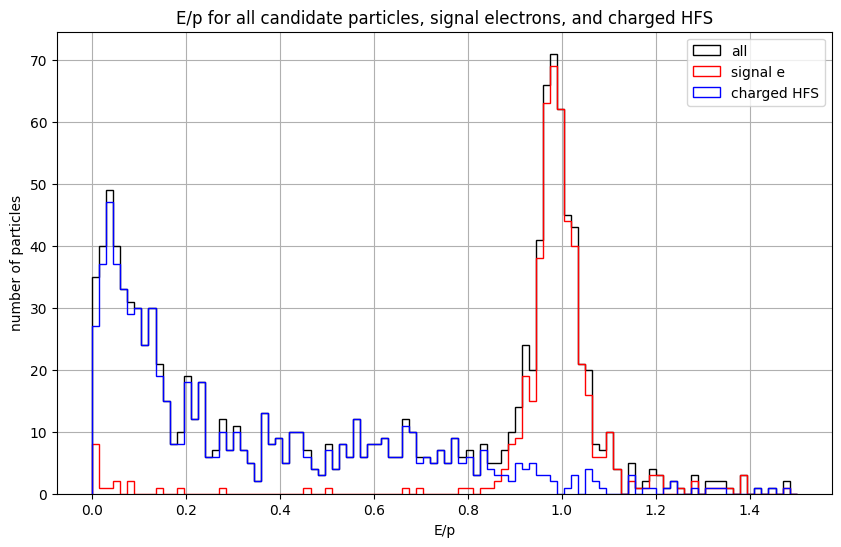

In [16]:
# plotting E/p using the vectorised matching results to verify they look the same
label_results = [
    build_mc_labels_per_reco(rec_ids, sim_ids, pdgs, gens, n)
    for rec_ids, sim_ids, pdgs, gens, n in zip(
        reco_to_mc_rec, reco_to_mc_sim, mc_pdg, mc_gen, ak.num(px_raw)
    )
]
mc_pdg_per_part = ak.Array([r[0] for r in label_results])
mc_gen_per_part = ak.Array([r[1] for r in label_results])
has_mc_per_part = ak.Array([r[2] for r in label_results])

# unified masks for all isolation / distribution plots
reco_has_mc = has_mc_per_part & (matched_calo_E_vec > 0)
is_signal_electron = reco_has_mc & (mc_gen_per_part == 1) & (mc_pdg_per_part == 11)
is_hfs = reco_has_mc & (mc_gen_per_part == 1) & (mc_pdg_per_part != 11)
matched_mask = matched_E_over_p_vec > 0

E_over_p_all_vec = ak.flatten(matched_E_over_p_vec[matched_mask])
E_over_p_signal_vec = ak.flatten(matched_E_over_p_vec[is_signal_electron])
E_over_p_hfs_vec = ak.flatten(matched_E_over_p_vec[is_hfs])
plt.figure(figsize=(10, 6))
plt.hist(E_over_p_all_vec, bins=100, range=(0, 1.5), histtype='step', color='black', label='all')
plt.hist(E_over_p_signal_vec, bins=100, range=(0, 1.5), histtype='step', color='red', label='signal e')
plt.hist(E_over_p_hfs_vec, bins=100, range=(0, 1.5), histtype='step', color='blue', label='charged HFS')
plt.xlabel('E/p')
plt.ylabel('number of particles')
plt.title('E/p for all candidate particles, signal electrons, and charged HFS')
plt.grid()
plt.legend()
plt.show()

### **Isolation**

Calculates isolation as the fraction of energy compared to the total energy. Meant to follow same flow as that from ElectronID code, also currently using $dR < 0.4$, as this is in ElectronID, must remember to test tweaking to see if this may affect the fitting.

Isolation code has been adapted to now take two inputs. Now it takes the ReconstructedCharged particles as candidates, as there's no point training off of particles that we know can't be electrons. It takes the total Reconstructed dataset for calculating the total energy deposit inside the cone, as they are still important, but no need to waste computational power on doing it for every single particle. Furthermore, the initial choice of cone_size = 0.4 wasn't great, increasing to 2.5 or even 3 has been amazing at discrimination at the 5x41 beam energy configuration. Will continue testing. 

Now, it iterates through each event using the candidate particle, and creates a cone dR. Then, it sums all the particles' energies inside the cone including the candidate particle. We then divide the candidates energy deposit by that sum. We expect a peak at 1 for signal, and a distribution peaking at 0 and teering off as it approaches 1, and this is what we see. 

In [17]:
# isolation - fully vectorised using awkward broadcasting
def calculate_isolation_vectorised(cand_eta, cand_phi, field_eta, field_phi, field_weight, cone_size=2.5):
    # cand shape:  [events, n_cand]
    # field shape: [events, n_field]
    # broadcast to [events, n_cand, n_field]

    c_eta = cand_eta[:, :, np.newaxis]   # [events, n_cand, 1]
    c_phi = cand_phi[:, :, np.newaxis]

    f_eta = field_eta[:, np.newaxis, :]  # [events, 1, n_field]
    f_phi = field_phi[:, np.newaxis, :]

    d_eta = f_eta - c_eta
    d_phi = f_phi - c_phi
    d_phi = ak.where(d_phi >  np.pi, d_phi - 2*np.pi, d_phi)
    d_phi = ak.where(d_phi < -np.pi, d_phi + 2*np.pi, d_phi)
    dR2 = d_eta**2 + d_phi**2

    in_cone = dR2 < cone_size**2  # compare dR² to avoid sqrt

    weights = field_weight[:, np.newaxis, :]  # [events, 1, n_field]
    iso_sum = ak.sum(ak.where(in_cone, weights, 0.0), axis=-1)  # [events, n_cand]

    return iso_sum

In [18]:
# converts the calorimeter hit positions from cartesian to pseudorapidity and azimuthal angle
def xyz_to_eta_phi(x, y, z):
    r_T = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    theta = np.arctan2(r_T, z)
    eta = -np.log(np.tan(theta / 2.0))
    return eta, phi

# necessary to find the positions of hits
barrel_eta_clu,  barrel_phi_clu  = xyz_to_eta_phi(barrel_pos_x,  barrel_pos_y,  barrel_pos_z)
endcapP_eta_clu, endcapP_phi_clu = xyz_to_eta_phi(endcapP_pos_x, endcapP_pos_y, endcapP_pos_z)
endcapN_eta_clu, endcapN_phi_clu = xyz_to_eta_phi(endcapN_pos_x, endcapN_pos_y, endcapN_pos_z)

# merge all three calorimeter systems into one per-event array
all_calo_eta = ak.concatenate([barrel_eta_clu, endcapP_eta_clu, endcapN_eta_clu], axis=1)
all_calo_phi = ak.concatenate([barrel_phi_clu, endcapP_phi_clu, endcapN_phi_clu], axis=1)
all_calo_E   = ak.concatenate([barrel_E, endcapP_E, endcapN_E], axis=1)

# match cluster eta, only worrying about reconstructed charged particles, as they're the actual candidates,
# so the cone is calculated wrt those particles

results_eta = [ 
    match_via_mc_vectorised(r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco)
    for r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco in zip(
        reco_to_mc_rec, reco_to_mc_sim,
        barrel_clu_idx, barrel_mc_idx, barrel_eta_clu,
        endcapP_clu_idx, endcapP_mc_idx, endcapP_eta_clu,
        endcapN_clu_idx, endcapN_mc_idx, endcapN_eta_clu,
        ak.num(px_raw)
    )
]
barrel_eta_per_part  = ak.Array([r[0] for r in results_eta])
endcapN_eta_per_part = ak.Array([r[1] for r in results_eta])
endcapP_eta_per_part = ak.Array([r[2] for r in results_eta])

# match cluster phi
results_phi = [
    match_via_mc_vectorised(r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco)
    for r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco in zip(
        reco_to_mc_rec, reco_to_mc_sim,
        barrel_clu_idx, barrel_mc_idx, barrel_phi_clu,
        endcapP_clu_idx, endcapP_mc_idx, endcapP_phi_clu,
        endcapN_clu_idx, endcapN_mc_idx, endcapN_phi_clu,
        ak.num(px_raw)
    )
]
barrel_phi_per_part  = ak.Array([r[0] for r in results_phi])
endcapN_phi_per_part = ak.Array([r[1] for r in results_phi])
endcapP_phi_per_part = ak.Array([r[2] for r in results_phi])

matched_calo_eta = ak.where(
    barrel_E_per_reco_vec > 0, barrel_eta_per_part,
    ak.where(
        endcapN_E_per_reco_vec > 0, endcapN_eta_per_part,
        ak.where(endcapP_E_per_reco_vec > 0, endcapP_eta_per_part, 0.0)
    )
)

matched_calo_phi = ak.where(
    barrel_E_per_reco_vec > 0, barrel_phi_per_part,
    ak.where(
        endcapN_E_per_reco_vec > 0, endcapN_phi_per_part,
        ak.where(endcapP_E_per_reco_vec > 0, endcapP_phi_per_part, 0.0)
    )
)

In [19]:
# isolation fraction using vectorised isolation calculation
iso_calo_total_vec = calculate_isolation_vectorised(
    matched_calo_eta, matched_calo_phi,
    all_calo_eta, all_calo_phi, all_calo_E, cone_size=0.8)

iso_frac_calo_vec = ak.where(
    has_matched_cluster,
    ak.where(iso_calo_total_vec > 0, matched_calo_E_vec / iso_calo_total_vec, 0.0),
    np.nan,
 )

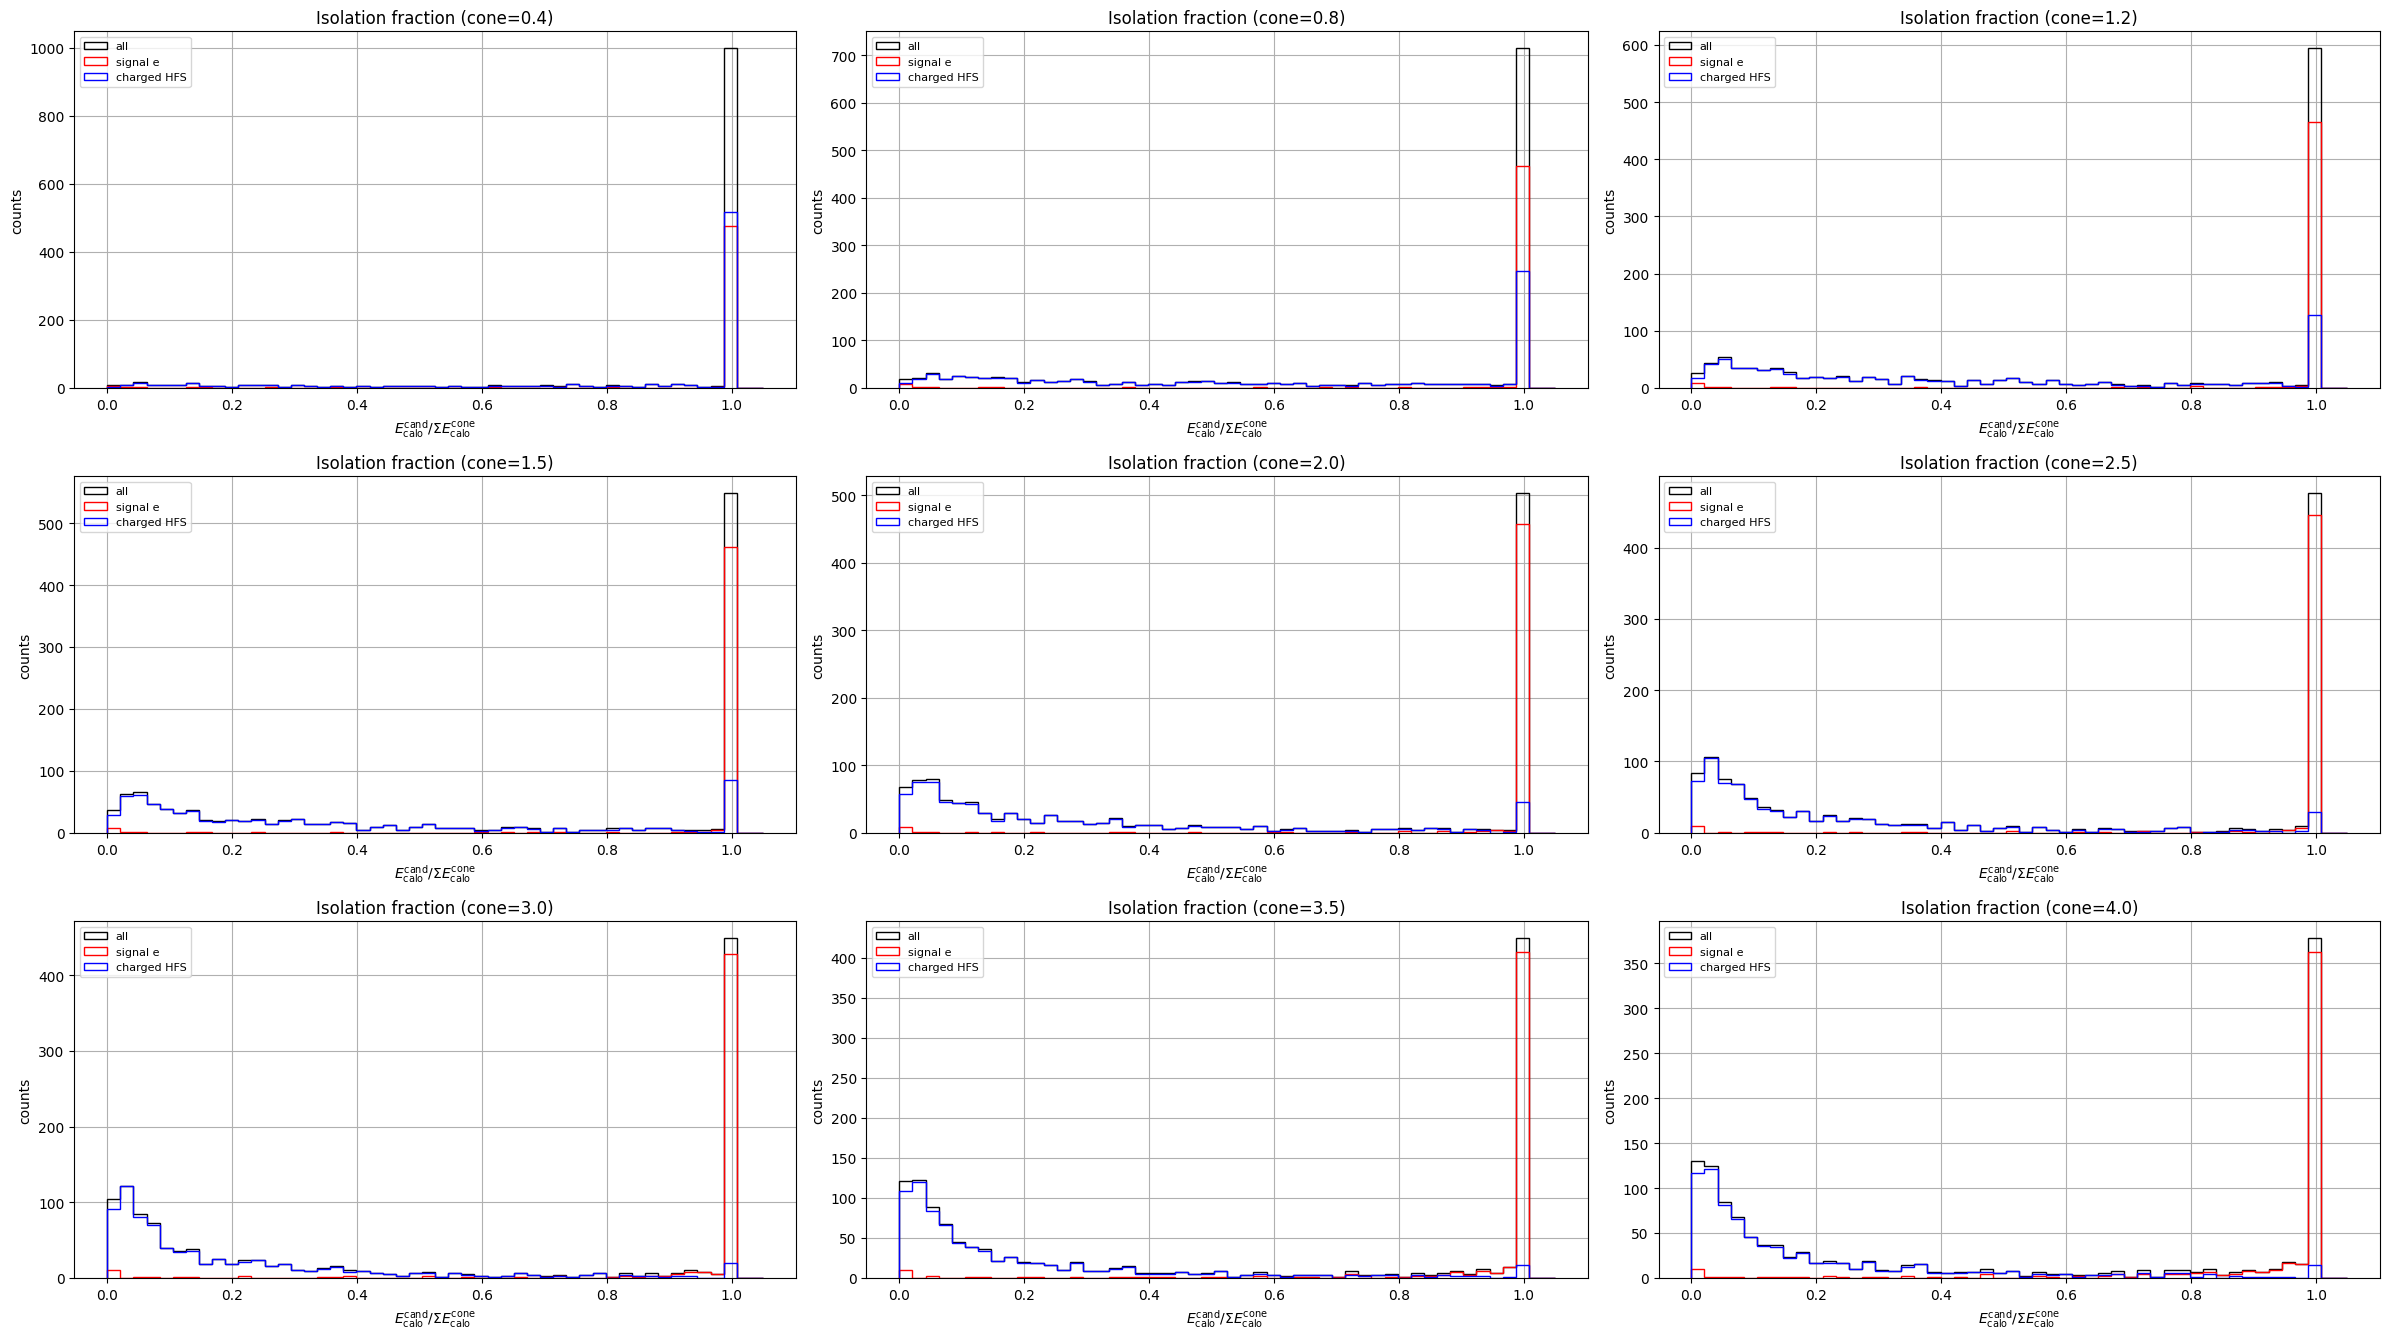

In [20]:
# plotting the isolation fraction using the vectorised isolation calculation for the same cone sizes
cone_sizes = [0.4, 0.8, 1.2, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
ncols = 3
nrows = int(np.ceil(len(cone_sizes) / ncols))


fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, cone in zip(axes, cone_sizes):
    iso_calo_cone_vec = calculate_isolation_vectorised(
        matched_calo_eta, matched_calo_phi,
        all_calo_eta, all_calo_phi, all_calo_E, cone_size=cone
    )
    iso_frac_calo_cone_vec = ak.where(iso_calo_cone_vec > 0, matched_calo_E_vec / iso_calo_cone_vec, 0.0)

    all_vals_vec = ak.flatten(iso_frac_calo_cone_vec[reco_has_mc])
    sig_vals_vec = ak.flatten(iso_frac_calo_cone_vec[is_signal_electron])
    hfs_vals_vec = ak.flatten(iso_frac_calo_cone_vec[is_hfs])

    ax.hist(all_vals_vec, bins=50, range=(0, 1.05), histtype='step', color='black', label='all')
    ax.hist(sig_vals_vec, bins=50, range=(0, 1.05), histtype='step', color='red', label='signal e')
    ax.hist(hfs_vals_vec, bins=50, range=(0, 1.05), histtype='step', color='blue', label='charged HFS')
    ax.set_xlabel(r'$E_{\mathrm{calo}}^{\mathrm{cand}} / \Sigma E_{\mathrm{calo}}^{\mathrm{cone}}$')
    ax.set_ylabel('counts')
    ax.set_title(f'Isolation fraction (cone={cone})')
    ax.grid(True)
    ax.legend(fontsize=8)

for ax in axes[len(cone_sizes):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

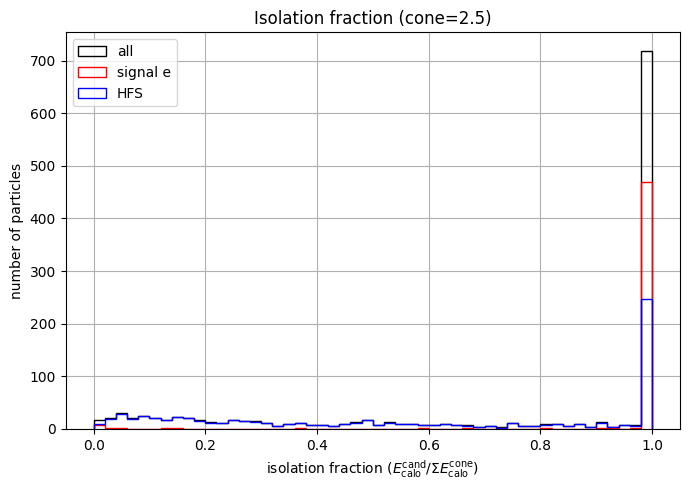

In [21]:
all_iso_calo = ak.flatten(iso_frac_calo_vec[reco_has_mc])
iso_signal_calo = ak.flatten(iso_frac_calo_vec[is_signal_electron])
iso_hfs_calo    = ak.flatten(iso_frac_calo_vec[is_hfs])

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(all_iso_calo, bins = 50, range=(0, 1), histtype='step', color='black', label='all')
ax.hist(iso_signal_calo, bins = 50, range=(0, 1), histtype='step', color='red',  label='signal e')
ax.hist(iso_hfs_calo, bins = 50, range=(0, 1), histtype='step', color='blue', label='HFS')
ax.set_xlabel(r'isolation fraction ($E_{\mathrm{calo}}^{\mathrm{cand}} / \Sigma E_{\mathrm{calo}}^{\mathrm{cone}}$)')
ax.set_ylabel('number of particles')
ax.set_title('Isolation fraction (cone=2.5)')
ax.grid()
ax.legend()
plt.tight_layout()
#plt.yscale('log')
plt.show()

In [22]:
# dR from candidate to nearest cluster
def calc_nearest_cluster_dR(cand_eta, cand_phi, field_eta, field_phi):
    min_dR_list = []
    for ev_c_eta, ev_c_phi, ev_f_eta, ev_f_phi in zip(
            cand_eta, cand_phi, field_eta, field_phi):
        ev_f_eta = ak.to_numpy(ev_f_eta)
        ev_f_phi = ak.to_numpy(ev_f_phi)
        for i in range(len(ev_c_eta)):
            c_eta = float(ev_c_eta[i])
            c_phi = float(ev_c_phi[i])
            if c_eta == 0.0 and c_phi == 0.0:
                continue  # skip unmatched
            d_eta = ev_f_eta - c_eta
            d_phi = ev_f_phi - c_phi
            d_phi = np.where(d_phi > np.pi, d_phi - 2*np.pi, d_phi)
            d_phi = np.where(d_phi < -np.pi, d_phi + 2*np.pi, d_phi)
            dR = np.sqrt(d_eta**2 + d_phi**2)
            dR = dR[dR > 1e-6]  # exclude self-match
            if len(dR) > 0:
                min_dR_list.append(np.min(dR))
    return np.array(min_dR_list)

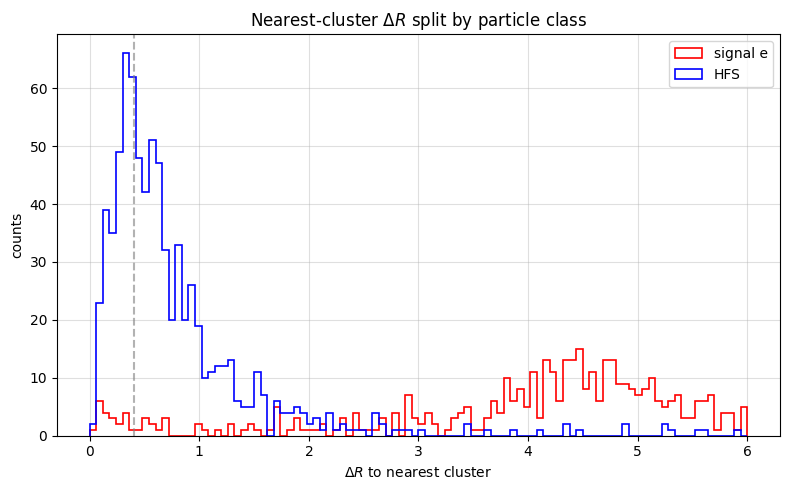

In [23]:
signal_calo_eta = ak.where(is_signal_electron, matched_calo_eta, 0.0)
signal_calo_phi = ak.where(is_signal_electron, matched_calo_phi, 0.0)

hfs_calo_eta = ak.where(is_hfs, matched_calo_eta, 0.0)
hfs_calo_phi = ak.where(is_hfs, matched_calo_phi, 0.0)

min_dR_signal = calc_nearest_cluster_dR(
    signal_calo_eta, signal_calo_phi,
    all_calo_eta, all_calo_phi)

min_dR_hfs = calc_nearest_cluster_dR(
    hfs_calo_eta, hfs_calo_phi,
    all_calo_eta, all_calo_phi)


fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(min_dR_signal, bins=100, range=(0, 6), histtype='step', color='red', linewidth=1.2, label='signal e')
ax.hist(min_dR_hfs, bins=100, range=(0, 6), histtype='step', color='blue', linewidth=1.2, label='HFS')
ax.axvline(0.4, color='grey', ls='--', alpha=0.6)
ax.set_xlabel(r'$\Delta R$ to nearest cluster')
ax.set_ylabel('counts')
ax.set_title(r'Nearest-cluster $\Delta R$ split by particle class')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### **Acoplanarity**

For each event, there are $n$ particles. Of these $n$ particles, a "candidate" electron is chosen. It has $p_{x}$ and $p_{y}$, so we're working in the transverse plane. For the other particles in the event, they each also have their own $p_{x}$ and $p_y$. They're summed to give a single "jet", so there is now candidate and jet. I want the opening angle between the candidate and the jet, given by
$$\vec{p}_{\text{candidate}} \cdot \vec{p}_{\text{jet}} = |\vec{p}_{\text{candidate}}||\vec{p}_{\text{jet}}|\cos(\Delta \phi),$$ so $\Delta \phi$ can be given by $$\Delta \phi = \cos^{-1}\left(\dfrac{\vec{p}_{\text{candidate}} \cdot \vec{p}_{\text{jet}}}{|\vec{p}_{\text{candidate}}||\vec{p}_{\text{jet}}|}\right).$$ Acoplanarity is then defined by $$A = \pi - \Delta \phi,$$ so that an acoplanarity of 0 implies two jets that are completely back to back.

The idea behind acoplanarity, is that the transverse momentum of the HFS should balance out that of the scattered electron, so for the actual scattered electron, the acoplanarity between it and the sum of the HFS, should tend to be back to back entirely.

In [24]:
# acoplanarity 
# set in same way, where we can use only ReconstructedCharged for candidates, and use Reconstructed for the field
def calc_acoplanarity(cand_px, cand_py, all_px, all_py):
    acoplanarity = []

    for ev_cand_px, ev_cand_py, ev_all_px, ev_all_py in zip(cand_px, cand_py, all_px, all_py):
        ev_cand_px = ak.to_numpy(ev_cand_px)
        ev_cand_py = ak.to_numpy(ev_cand_py)
        ev_all_px  = ak.to_numpy(ev_all_px) # takes the Reconstructed particles 
        ev_all_py  = ak.to_numpy(ev_all_py)

        n_cand = len(ev_cand_px)

        total_px = np.sum(ev_all_px)  # sum over ALL particles
        total_py = np.sum(ev_all_py)
        event_acoplanarity = []

        for i in range(n_cand):
            cpx = ev_cand_px[i] # candidate
            cpy = ev_cand_py[i]
            recoil_px = total_px - cpx  # recoil = all - candidate
            recoil_py = total_py - cpy
            cand_mag = np.sqrt(cpx**2 + cpy**2)
            recoil_mag = np.sqrt(recoil_px**2 + recoil_py**2)

            if cand_mag == 0 or recoil_mag == 0:
                event_acoplanarity.append(0.0)
                continue

            cos_dphi = (cpx * recoil_px + cpy * recoil_py) / (cand_mag * recoil_mag)
            cos_dphi = np.clip(cos_dphi, -1.0, 1.0)
            dphi = np.arccos(cos_dphi)
            event_acoplanarity.append(np.pi - dphi)

        acoplanarity.append(event_acoplanarity)

    return ak.Array(acoplanarity)

acoplanarity = calc_acoplanarity(boosted_px, boosted_py, boosted_px, boosted_py)

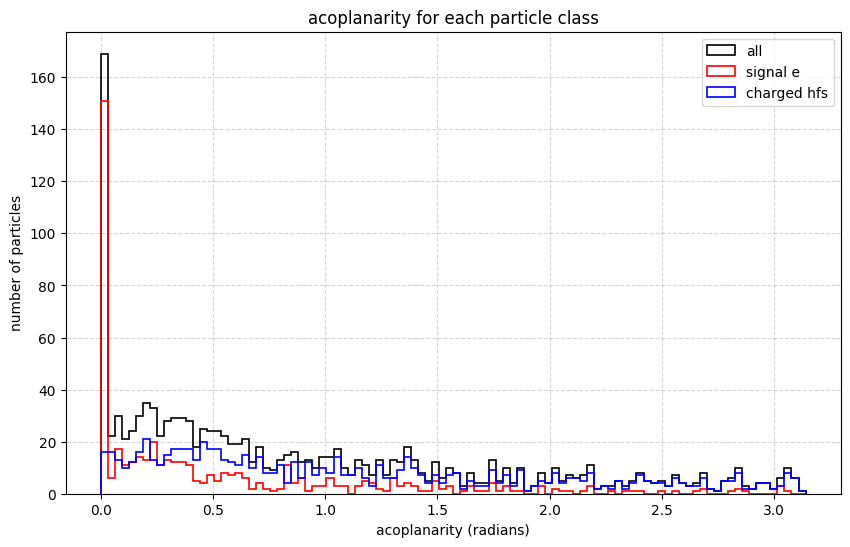

In [25]:
# acoplanarity distribution

aco_all    = ak.flatten(acoplanarity[matched_mask])
aco_signal = ak.flatten(acoplanarity[is_signal_electron])
aco_hfs    = ak.flatten(acoplanarity[is_hfs])


plt.figure(figsize=(10, 6))
bins = 100
plot_range = (0, np.pi) 

plt.hist(aco_all, bins=bins, range=plot_range, histtype='step', 
         color='black', label='all', linewidth=1.2)
plt.hist(aco_signal, bins=bins, range=plot_range, histtype='step', 
         color='red', label='signal e', linewidth=1.2)
plt.hist(aco_hfs, bins=bins, range=plot_range, histtype='step', 
         color='blue', label='charged hfs', linewidth=1.2)

plt.xlabel('acoplanarity (radians)')
plt.ylabel('number of particles')
plt.title('acoplanarity for each particle class')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

### **Greatest $p_{T}$**

The scattered electron typically has the greatest transverse momentum per event.

In [26]:
def find_greatest_pt(pt_array):
    is_leading = []
    for event_pt in pt_array:
        if len(event_pt) == 0:
            is_leading.append([]) # for event with no particles, edge case to stop it breaking
        else:
            max_index = ak.argmax(event_pt) # finds index of max pt value for event
            event_flags = [i == max_index for i in range(len(event_pt))]
            is_leading.append(event_flags)
    return ak.Array(is_leading)

In [27]:
# greatest pt among charged candidates

is_leading_pt = find_greatest_pt(pt)

In [28]:
# E / H 


### **Compiling the features**

At this point all the features have been found. If new features are to be tested, they must be done before this code block, and their features must be inputted here. Candidates are now all reconstructed charged particles.

Particles without a matched cluster are kept in the dataset. For those entries, cluster-dependent features (`E_over_p` and `isolation_frac`) are set to `NaN` instead of being removed.

Also, Bjorken values are compiled per event and per particle. This is because they're calculated on an event-level, but for plotting later, I need them to match to the individual particles for plotting.

In [29]:
# event level feature arrays

# keep one value per event (preserves event count)
Q2_per_event = ak.firsts(trueQ2)
x_per_event = ak.firsts(truex)
y_per_event = ak.firsts(truey)

# optional: fill missing events with 0 (or np.nan if you prefer)
Q2_per_event = ak.fill_none(Q2_per_event, 0.0)
x_per_event = ak.fill_none(x_per_event, 0.0)
y_per_event = ak.fill_none(y_per_event, 0.0)

# broadcast to per-charged-particle (candidates are charged tracks now)
Q2_per_particle = ak.flatten(ak.broadcast_arrays(Q2_per_event, boosted_px)[0])
x_per_particle = ak.flatten(ak.broadcast_arrays(x_per_event, boosted_px)[0])
y_per_particle = ak.flatten(ak.broadcast_arrays(y_per_event, boosted_px)[0])
# create event index to track which particles belong to which event
event_index = ak.flatten(ak.broadcast_arrays(ak.local_index(boosted_px, axis=0), boosted_px)[0])

In [30]:
# build per-charged-particle labels using the robust recID/simID lookup
labels = []
for rec_ids, sim_ids, pdgs, gens, n in zip(
        reco_to_mc_rec, reco_to_mc_sim, mc_pdg, mc_gen, ak.num(boosted_px)):
    # find first final-state electron MC index
    target_mc = -1
    for idx, (pdg, gen) in enumerate(zip(pdgs, gens)):
        if pdg == 11 and gen == 1:
            target_mc = idx
            break
    # build recID -> simID map, then label = 1 if the charged track is matched to that electron
    mc_for_reco = [None] * n
    for rec_id, sim_id in zip(rec_ids, sim_ids):
        ri = int(rec_id)
        if 0 <= ri < n:
            mc_for_reco[ri] = int(sim_id)
    lab = [1 if mc_for_reco[i] == target_mc and target_mc >= 0 else 0 for i in range(n)]
    labels.append(lab)

labels = ak.Array(labels)

# flatten features and labels — all indexed by charged particles now
E_over_p_feat = ak.flatten(matched_E_over_p_vec)
iso_feat = ak.flatten(iso_frac_calo_vec)
leading_pt_feat = ak.flatten(is_leading_pt)
charge_feat = ak.flatten(charge)
acoplanarity_feat = ak.flatten(acoplanarity)
#jet_acoplanarity_feat = ak.flatten(aco_leading_jet)
pt_feat = ak.flatten(pt)
labs = ak.flatten(labels)

# keep all charged candidates; unmatched-cluster particles remain with NaN
Q2_feat = Q2_per_particle
x_feat = x_per_particle
y_feat = y_per_particle
event_idx_feat = event_index

X_df = pd.DataFrame({
    "E_over_p": ak.to_numpy(E_over_p_feat),
    "isolation_frac": ak.to_numpy(iso_feat),
    "is_leading_pt": ak.to_numpy(leading_pt_feat).astype(int),
    "charge": ak.to_numpy(charge_feat),
    "acoplanarity": ak.to_numpy(acoplanarity_feat),
    #"jet_acoplanarity": ak.to_numpy(jet_acoplanarity_feat),
    "pt": ak.to_numpy(pt_feat),
    "Q2": ak.to_numpy(Q2_feat),
    "x": ak.to_numpy(x_feat),
    "y": ak.to_numpy(y_feat),
    "event_id": ak.to_numpy(event_idx_feat)
})

y = ak.to_numpy(labs)

In [31]:
# determining ratio of scattered electrons to background to inform scale_pos_weight
unique, counts = np.unique(y, return_counts=True)
n_background = counts[0]
n_signal = counts[1]
scale_pos_weight = n_background / n_signal
print(scale_pos_weight)


2.682092555331992


## **Training**

I chose AUC as online it said this is the best way to go. Currently, only scale_pos_weight is motivated by reality, others are picked according to examples online (SERB tutorial) or defaults, must remember to tweak.

### **Switching to sklearn wrapper instead of native XGBoost API**

Switched the training here from native API that i was using before to now using XGBClassifier. Found it easier to match to examples in the tutorial notebook, and gives me much less trouble with the plot_importances.

In [32]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# split events
unique_events = X_df['event_id'].unique()  # fetches all unique event IDs
train_events, val_events = train_test_split(unique_events, test_size=0.2, random_state=42)

train_mask = X_df['event_id'].isin(train_events)  # split rows based on event IDs
val_mask = X_df['event_id'].isin(val_events)

# --- truth check using the same logic as labels: first final-state electron only ---
# supervisor rule interpreted exactly as in labeling cell: first MC particle with (pdg==11 and gen==1)
n_true_scattered_e_train = 0
n_train_events_with_no_truth_e = 0
for ev in train_events:
    ev_idx = int(ev)
    ev_pdgs = np.asarray(mc_pdg[ev_idx])
    ev_gens = np.asarray(mc_gen[ev_idx])

    target_mc = -1
    for idx, (pdg, gen) in enumerate(zip(ev_pdgs, ev_gens)):
        if pdg == 11 and gen == 1:
            target_mc = idx
            break

    if target_mc >= 0:
        n_true_scattered_e_train += 1
    else:
        n_train_events_with_no_truth_e += 1

print(f"train events: {len(train_events)}")
print(f"true scattered electrons in train events (same first-match logic as labels): {n_true_scattered_e_train}")
print(f"train events with no truth scattered electron found: {n_train_events_with_no_truth_e}")

X = np.asarray(X_df[["E_over_p", "isolation_frac", "is_leading_pt", "charge", "pt", "acoplanarity"]])  # features for training
y = np.asarray(y)

X_train = X[train_mask]
X_val = X[val_mask]
y_train = y[train_mask]
y_val = y[val_mask]

# event information for plotting efficiency and purity later
event_info_df = X_df[["Q2", "x", "y", "event_id"]]
event_info_val = event_info_df[val_mask]

print(f"training on {len(train_events)} events ({len(X_train)} particles)")
print(f"validating on {len(val_events)} events ({len(X_val)} particles)")
print(f"true electrons in train: {y_train.sum()}")
print(f"true electrons in val: {y_val.sum()}")

feature_names = ["E/p", "isolation fraction", "leading transverse momentum", "charge", "transverse momentum", "acoplanarity"]

# training using sklearn API
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    eta=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    use_label_encoder=False,
    early_stopping_rounds=20
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)  # verbose=True to show training progress

train events: 404
true scattered electrons in train events (same first-match logic as labels): 404
train events with no truth scattered electron found: 0
training on 404 events (1427 particles)
validating on 101 events (403 particles)
true electrons in train: 398
true electrons in val: 99
[0]	validation_0-auc:0.98565
[1]	validation_0-auc:0.98575
[2]	validation_0-auc:0.98599
[3]	validation_0-auc:0.98729
[4]	validation_0-auc:0.98884
[5]	validation_0-auc:0.98857
[6]	validation_0-auc:0.98900
[7]	validation_0-auc:0.98923
[8]	validation_0-auc:0.98907
[9]	validation_0-auc:0.98910
[10]	validation_0-auc:0.98920
[11]	validation_0-auc:0.98923
[12]	validation_0-auc:0.98920
[13]	validation_0-auc:0.98927
[14]	validation_0-auc:0.98942
[15]	validation_0-auc:0.98928
[16]	validation_0-auc:0.98892
[17]	validation_0-auc:0.98895
[18]	validation_0-auc:0.98902
[19]	validation_0-auc:0.98894
[20]	validation_0-auc:0.99236
[21]	validation_0-auc:0.99262
[22]	validation_0-auc:0.99244
[23]	validation_0-auc:0.99241


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [33]:
from pathlib import Path

out_dir = Path("home/user321/EIC-Project-25-26/arthur/projectxg/model_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

model_path = out_dir / "xgb_10x275_ip.json"
model.save_model(model_path)
print(f"Model saved to {model_path}")

val_path = out_dir / "xgb_10x275_ip_val.csv"
np.savez_compressed(val_path, X_val=X_val, y_val=y_val, val_pred=model.predict_proba(X_val)[:, 1], event_info=event_info_val, feature_names=feature_names)

Model saved to home/user321/EIC-Project-25-26/arthur/projectxg/model_outputs/xgb_10x275_ip.json


train AUC (sklearn): 1.000
validation AUC (sklearn): 0.993


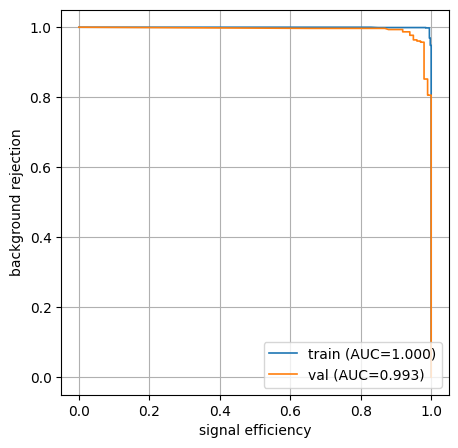

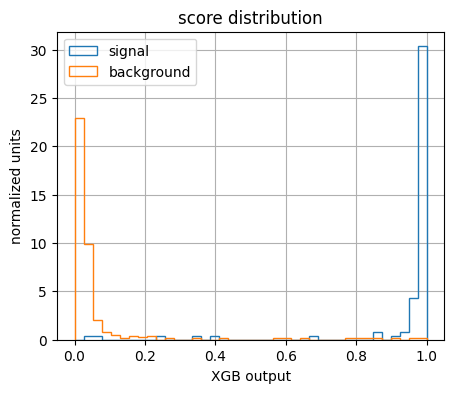

In [34]:
from sklearn.metrics import roc_curve, auc


train_pred_sklearn = model.predict_proba(X_train)[:, 1] # gets the predicted probabilities for the positive class
val_pred_sklearn = model.predict_proba(X_val)[:, 1]



fpr_train_sklearn, tpr_train_sklearn, _ = roc_curve(y_train, train_pred_sklearn)
fpr_val_sklearn, tpr_val_sklearn, _ = roc_curve(y_val, val_pred_sklearn)



train_auc_sklearn = auc(fpr_train_sklearn, tpr_train_sklearn)
val_auc_sklearn = auc(fpr_val_sklearn, tpr_val_sklearn)


print(f"train AUC (sklearn): {train_auc_sklearn:.3f}")
print(f"validation AUC (sklearn): {val_auc_sklearn:.3f}")




# roc curve using sklearn wrapper
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(tpr_train_sklearn, 1 - fpr_train_sklearn, lw=1.2, label=f"train (AUC={train_auc_sklearn:.3f})") # 1 - fpr to give background rejection
ax.plot(tpr_val_sklearn, 1 - fpr_val_sklearn, lw=1.2, label=f"val (AUC={val_auc_sklearn:.3f})")
ax.set_xlabel("signal efficiency")
ax.set_ylabel("background rejection")
ax.set_title = ("roc curve")
ax.grid(True)
ax.legend(loc="lower right")
plt.show()




# score distribution using sklearn
bins = np.linspace(0, 1, 40)
sig_scores_sk = val_pred_sklearn[y_val == 1]
bkg_scores_sk = val_pred_sklearn[y_val == 0]
fig, ax = plt.subplots(figsize=(5,4))
ax.hist(sig_scores_sk, bins = bins, histtype = "step", density = True, label = "signal")
ax.hist(bkg_scores_sk, bins = bins, histtype = "step", density = True, label = "background")
ax.set_xlabel("XGB output")
ax.set_ylabel("normalized units")
ax.set_title("score distribution")
ax.legend()
ax.grid(True)
plt.show()

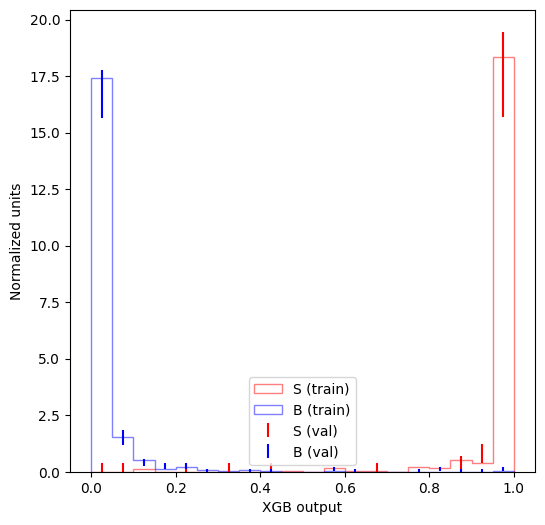

In [35]:
def compare_train_test(model, X_train, y_train, X_test, y_test, bins=20):
    decisions = []
    for X, y in ((X_train, y_train), (X_test, y_test)):
        scores = model.predict_proba(X)[:, 1]
        d1 = scores[y > 0.5].ravel()  # .ravel() to ensure 1D hist for use with plt.hist()
        d2 = scores[y < 0.5].ravel()
        decisions += [d1, d2]

    plt.subplots(figsize=(6, 6))
    plt.hist(decisions[0],
             color="r", alpha=0.5, range=(0, 1), bins=bins,
             histtype="step", density=1,
             label="S (train)")
    plt.hist(decisions[1],
             color="b", alpha=0.5, range=(0, 1), bins=bins,
             histtype="step", density=1,
             label="B (train)")

    hist, bins = np.histogram(decisions[2], bins=bins, range=(0, 1), density=1)
    scale = len(decisions[2]) / sum(hist)
    err = np.sqrt(hist * scale) / scale

    width = (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    plt.errorbar(center, hist, yerr=err, fmt="none", c="r", label="S (val)")

    hist, bins = np.histogram(decisions[3], bins=bins, range=(0, 1), density=1)
    scale = len(decisions[3]) / sum(hist)
    err = np.sqrt(hist * scale) / scale

    plt.errorbar(center, hist, yerr=err, fmt="none", c="b", label="B (val)")

    plt.xlabel("XGB output")
    plt.ylabel("Normalized units")
    plt.legend(loc="best")
    #plt.savefig("Xgboutput.png", bbox_inches="tight")

compare_train_test(model, X_train, y_train, X_val, y_val)

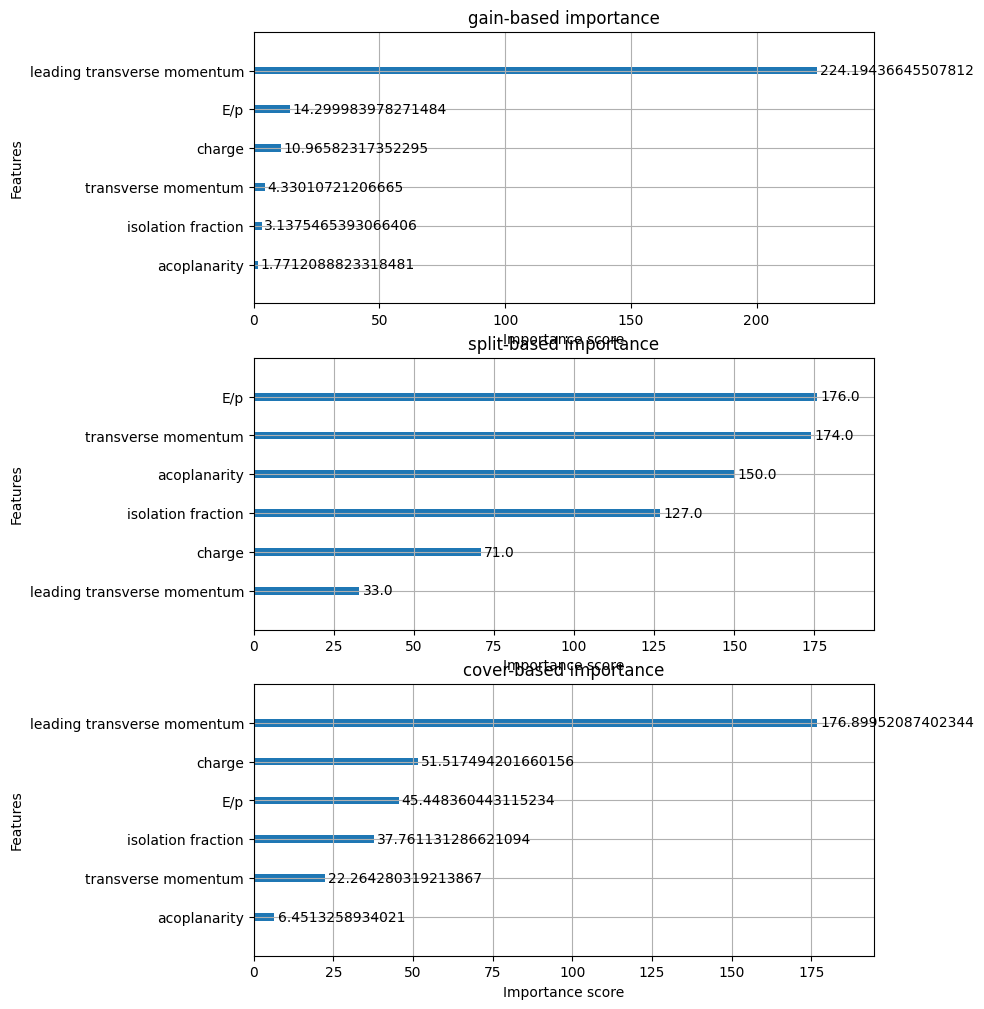

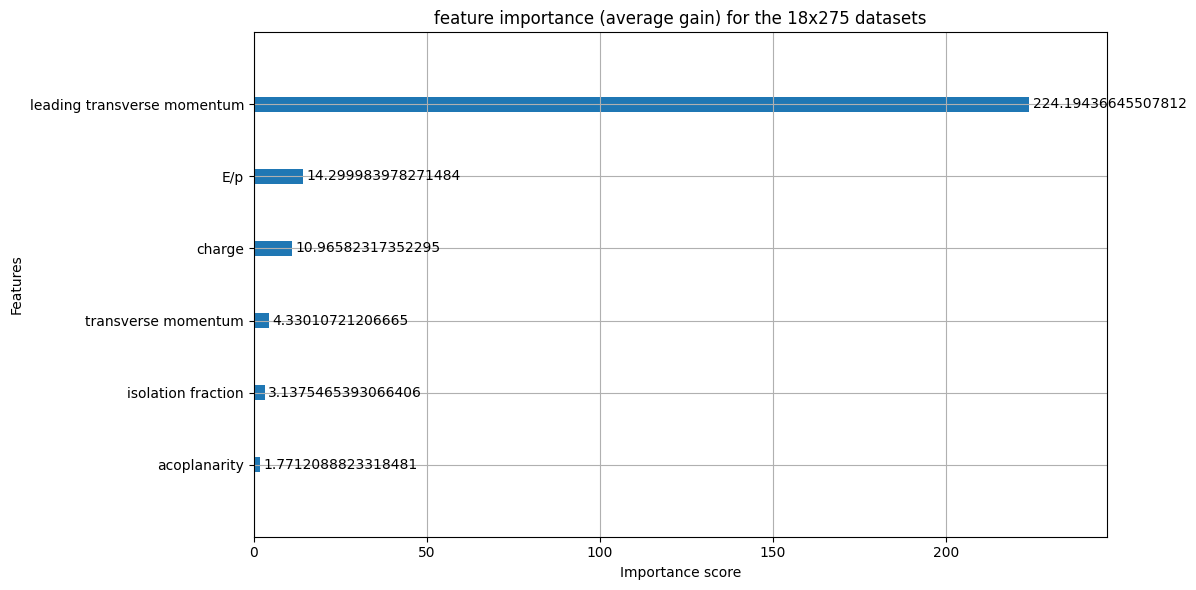

In [36]:
# three different types of importance
booster = model.get_booster()
booster.feature_names = feature_names

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (8, 12))

xgb.plot_importance(booster, ax = ax1, importance_type = "gain")
ax1.set_title("gain-based importance")

xgb.plot_importance(booster, ax = ax2, importance_type = "weight")
ax2.set_title("split-based importance")

xgb.plot_importance(booster, ax = ax3, importance_type = "cover")
ax3.set_title("cover-based importance")

fig, ax = plt.subplots(figsize=(12, 6))
xgb.plot_importance(booster, ax=ax, importance_type="gain")
ax.set_title("feature importance (average gain) for the 18x275 datasets")
plt.tight_layout()
plt.show()



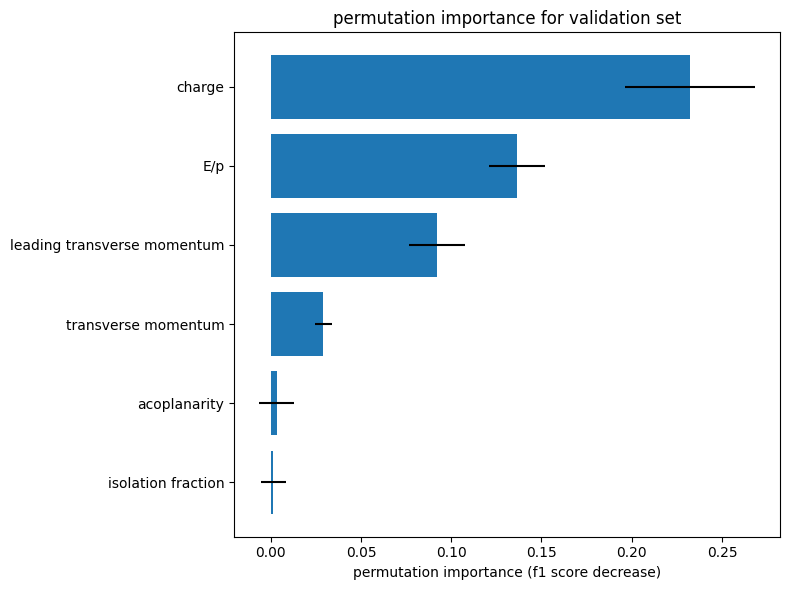

In [37]:
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_val, y_val, scoring = 'f1', n_repeats=10, random_state=42)

importances_mean = result.importances_mean
importances_std = result.importances_std
sorted_idx = np.argsort(importances_mean)[::-1]

sorted_means = importances_mean[sorted_idx]
sorted_stds = importances_std[sorted_idx]
sorted_features = np.array(feature_names)[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sorted_features, sorted_means, xerr=sorted_stds, align='center')
ax.invert_yaxis()  # highest importance at the top
ax.set_xlabel("permutation importance (f1 score decrease)")
ax.set_title("permutation importance for validation set")
plt.tight_layout()
plt.show()

In [38]:
print(event_info_val['Q2'].values.argmax())

0


In [39]:
def efficiency_purity_vs_bjorken(val_pred, yval, event_info_val, threshold = 0.5):
    predicted_electrons = val_pred > threshold
    
    Q2_bins = np.geomspace(1, 10, num = 50)
    Q2_values = event_info_val['Q2'].values

    #x_bins = np.logspace(-3, 0, base = 10)
    x_bins = np.geomspace(1e-2, 1, num = 50)
    x_values = event_info_val['x'].values

    #y_bins = np.logspace(-3, 0, base = 10)
    y_bins = np.geomspace(10e-3, 0.999999, num = 50)
    y_values = event_info_val['y'].values

    efficiencies_Q2 = []
    purities_Q2 = []
    bin_centers_Q2 = []

    efficiencies_x = []
    purities_x = []
    bin_centers_x = []

    efficiencies_y = []
    purities_y = []
    bin_centers_y = []

    true_electrons_per_bin_Q2 = []
    true_electrons_per_bin_x = []
    true_electrons_per_bin_y = []

    
    # begin with Q2
    for bin in range(len(Q2_bins) - 1):
        bin_bottom = Q2_bins[bin]
        bin_top = Q2_bins[bin + 1]
        bin_center = (bin_bottom + bin_top) / 2
        bin_centers_Q2.append(bin_center)

        in_bin = (Q2_values >= bin_bottom) & (Q2_values < bin_top)

        if np.sum(in_bin) == 0: # just incase there are no events in the bin
            efficiencies_Q2.append(0)
            purities_Q2.append(0)
            true_electrons_per_bin_Q2.append(0)
            continue

        y_true_bin = y_val[in_bin]
        y_pred_bin = predicted_electrons[in_bin]

        tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1)) # true positives
        fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1)) # false positives
        fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0)) # false negatives

        efficiency = tp / (tp + fn)
        purity = tp / (tp + fp)

        efficiencies_Q2.append(efficiency)
        purities_Q2.append(purity)
        true_electrons_per_bin_Q2.append(np.sum(y_true_bin == 1))
    
    # now x
    for bin in range(len(x_bins) - 1):
        bin_bottom = x_bins[bin]
        bin_top = x_bins[bin + 1]
        bin_center = (bin_bottom + bin_top) / 2
        bin_centers_x.append(bin_center)

        in_bin = (x_values >= bin_bottom) & (x_values < bin_top)

        if np.sum(in_bin) == 0: # just incase there are no events in the bin
            efficiencies_x.append(0)
            purities_x.append(0)
            true_electrons_per_bin_x.append(0)
            continue

        y_true_bin = y_val[in_bin]
        y_pred_bin = predicted_electrons[in_bin]

        tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1)) # true positives
        fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1)) # false positives
        fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0)) # false negatives

        efficiency = tp / (tp + fn)
        purity = tp / (tp + fp)

        efficiencies_x.append(efficiency)
        purities_x.append(purity)
        true_electrons_per_bin_x.append(np.sum(y_true_bin == 1))
    
    # now y
    for bin in range(len(y_bins) - 1):
        bin_bottom = y_bins[bin]
        bin_top = y_bins[bin + 1]
        bin_center = (bin_bottom + bin_top) / 2
        bin_centers_y.append(bin_center)

        in_bin = (y_values >= bin_bottom) & (y_values < bin_top)

        if np.sum(in_bin) == 0: # just incase there are no events in the bin
            efficiencies_y.append(0)
            purities_y.append(0)
            true_electrons_per_bin_y.append(0)
            continue

        y_true_bin = y_val[in_bin]
        y_pred_bin = predicted_electrons[in_bin]

        tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1)) # true positives
        fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1)) # false positives
        fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0)) # false negatives

        efficiency = tp / (tp + fn)
        purity = tp / (tp + fp)

        efficiencies_y.append(efficiency)
        purities_y.append(purity)
        true_electrons_per_bin_y.append(np.sum(y_true_bin == 1))

    return (bin_centers_Q2, efficiencies_Q2, purities_Q2,
            bin_centers_x, efficiencies_x, purities_x,
            bin_centers_y, efficiencies_y, purities_y, true_electrons_per_bin_Q2, true_electrons_per_bin_x, true_electrons_per_bin_y)

In [40]:
evaluation_results = efficiency_purity_vs_bjorken(val_pred_sklearn, y_val, event_info_val, threshold = 0.5)

In [41]:
bin_centers_Q2, efficiencies_Q2, purities_Q2, bin_centers_x, efficiencies_x, purities_x, bin_centers_y, efficiencies_y, purities_y, true_electrons_per_bin_Q2, true_electrons_per_bin_x, true_electrons_per_bin_y = evaluation_results

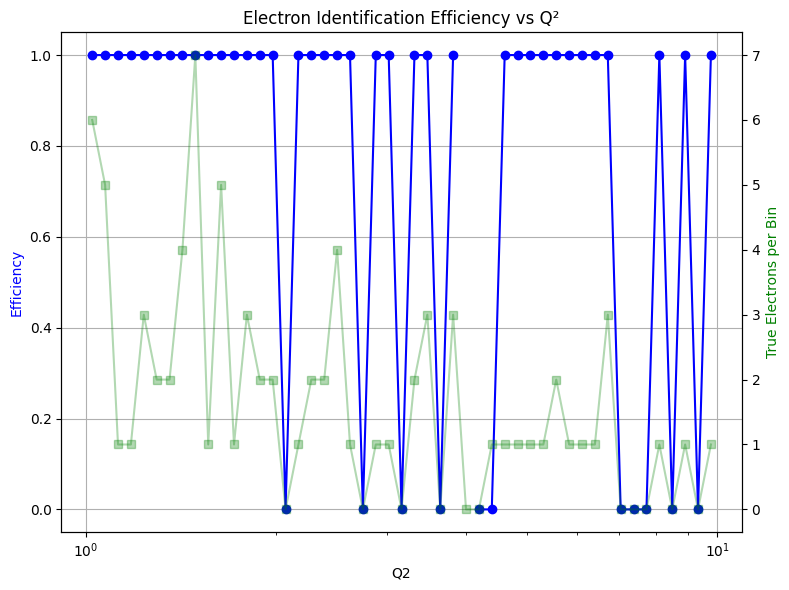

In [42]:
# Q2 efficiency plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_Q2, efficiencies_Q2, marker='o', color='b', label='Efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('Q2')
ax1.set_ylabel('Efficiency', color='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_Q2, true_electrons_per_bin_Q2, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')
ax2.set_ylabel('True Electrons per Bin', color='g')

plt.title('Electron Identification Efficiency vs Q²')
fig.tight_layout()
plt.show()

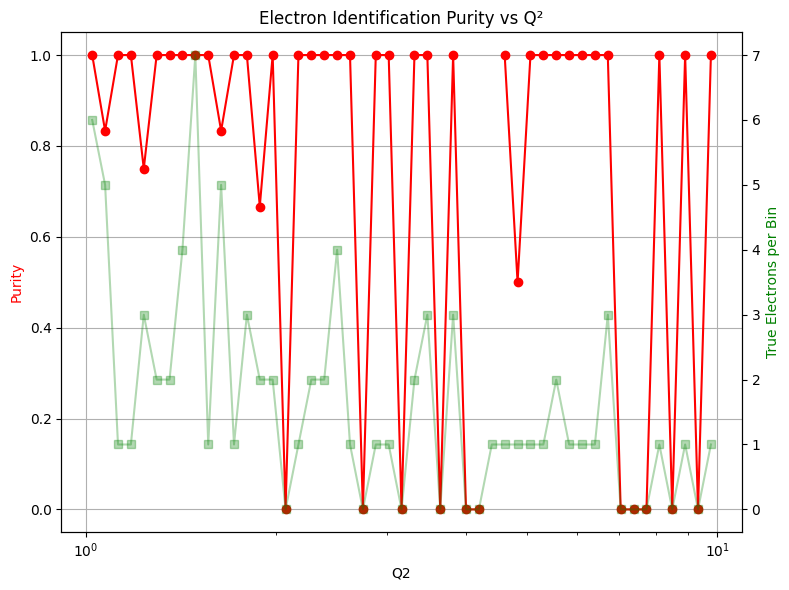

In [43]:
# Q2 purity plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_Q2, purities_Q2, marker='o', color='r', label='Purity')
ax1.set_xscale('log')
ax1.set_xlabel('Q2')
ax1.set_ylabel('Purity', color='r')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_Q2, true_electrons_per_bin_Q2, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')
ax2.set_ylabel('True Electrons per Bin', color='g')

plt.title('Electron Identification Purity vs Q²')
fig.tight_layout()
plt.show()

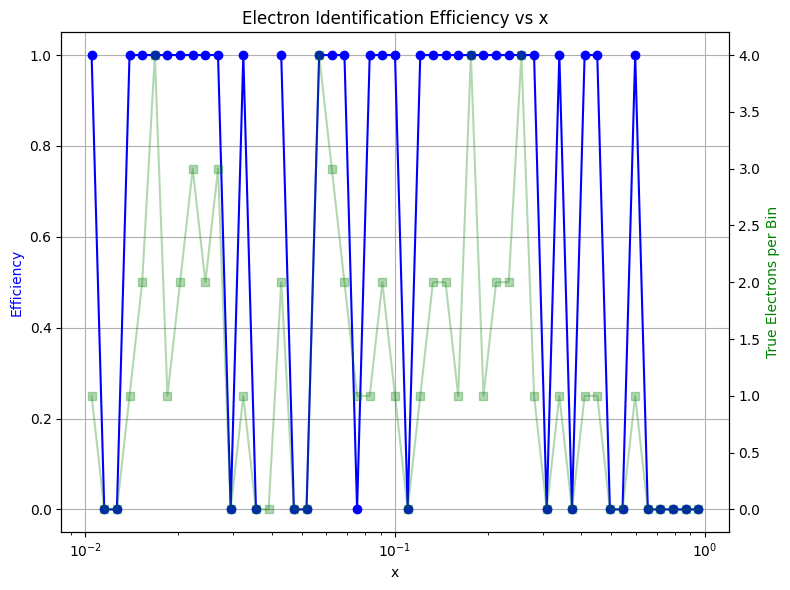

In [44]:
# x efficiency plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_x, efficiencies_x, marker='o', color='b', label='Efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('x')
ax1.set_ylabel('Efficiency', color='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_x, true_electrons_per_bin_x, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')

ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Efficiency vs x')
fig.tight_layout()
plt.show()

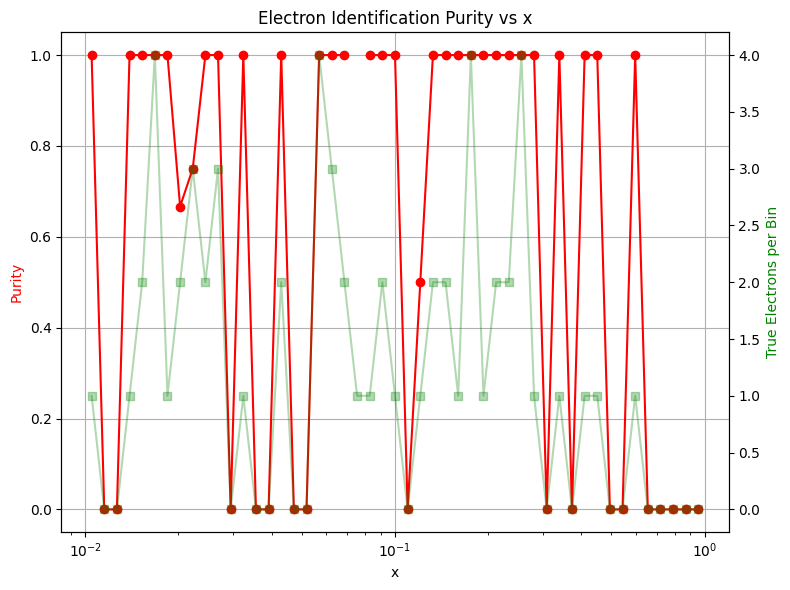

In [45]:
# x purity plotting

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_x, purities_x, marker='o', color='r', label='Purity')
ax1.set_xscale('log')
ax1.set_xlabel('x')
ax1.set_ylabel('Purity', color='r')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_x, true_electrons_per_bin_x, marker='s', color='g', alpha = 0.3, label='T,rue Electrons per Bin')
ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Purity vs x')
fig.tight_layout()
plt.show()

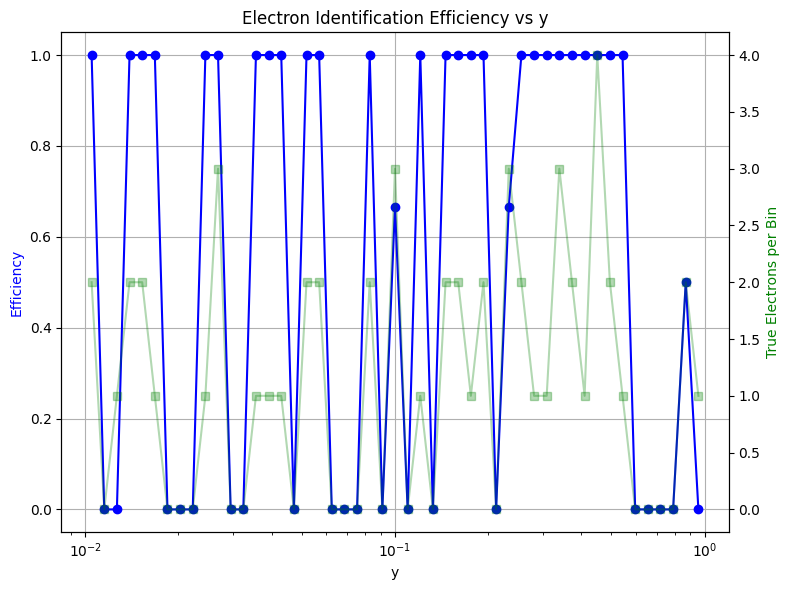

In [46]:
# y efficiency plotting
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_y, efficiencies_y, marker='o', color='b', label='Efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('y')
ax1.set_ylabel('Efficiency', color='b')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_y, true_electrons_per_bin_y, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')

ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Efficiency vs y')
fig.tight_layout()
plt.show()

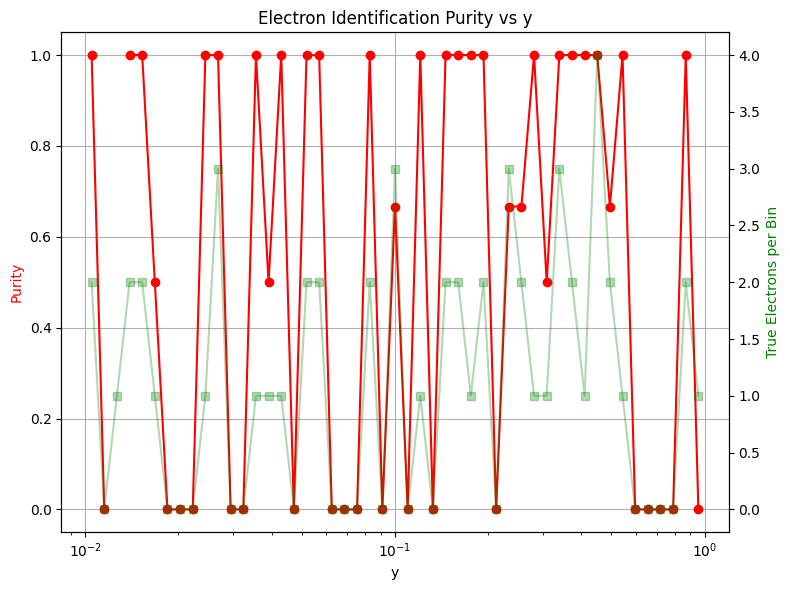

In [47]:
# y purity plotting
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(bin_centers_y, purities_y, marker='o', color='r', label='Purity')
ax1.set_xscale('log')
ax1.set_xlabel('y')
ax1.set_ylabel('Purity', color='r')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_centers_y, true_electrons_per_bin_y, marker='s', color='g', alpha = 0.3, label='True Electrons per Bin')

ax2.set_ylabel('True Electrons per Bin', color='g')
plt.title('Electron Identification Purity vs y')
fig.tight_layout()
plt.show()

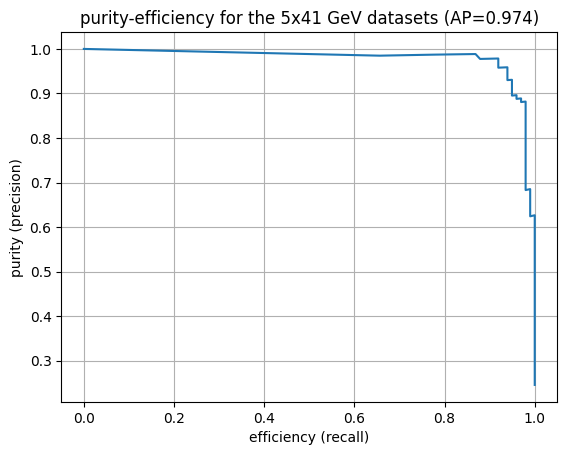

In [48]:
# precision-recall curve -> same as purity-efficiency curve but using a given function from sklearn
from sklearn.metrics import precision_recall_curve, average_precision_score 

precision, recall, thresholds = precision_recall_curve(y_val, val_pred_sklearn)
ap = average_precision_score(y_val, val_pred_sklearn)

plt.plot(recall, precision)
plt.xlabel('efficiency (recall)')
plt.ylabel('purity (precision)')
plt.title(f'purity-efficiency for the 5x41 GeV datasets (AP={ap:.3f})')
plt.grid(True)
plt.show()

Text(0.5, 0.98, 'Partial Dependence Plots')

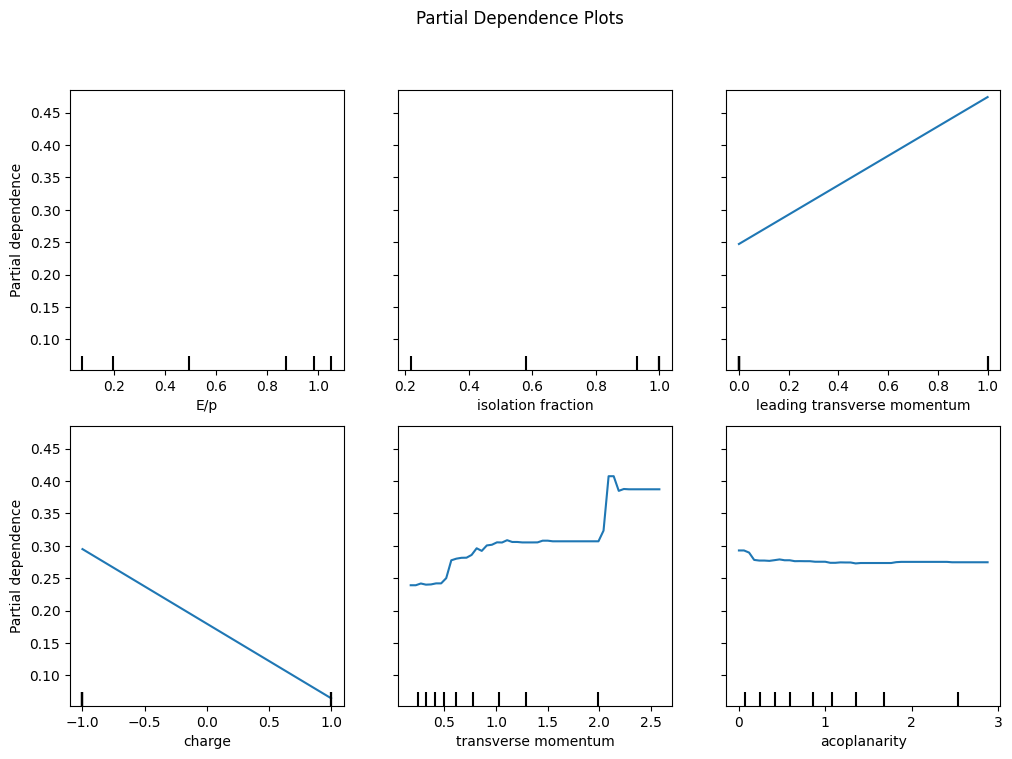

In [49]:
# PDP plotting

from sklearn.inspection import PartialDependenceDisplay
features_to_plot = [0, 1, 2, 3, (0, 1), (0, 2)]
fig, ax = plt.subplots(figsize = (12, 8))
PartialDependenceDisplay.from_estimator(model, X_val, features = [0, 1, 2, 3, 4, 5], feature_names = feature_names, ax=ax, grid_resolution = 50)
plt.suptitle("Partial Dependence Plots")

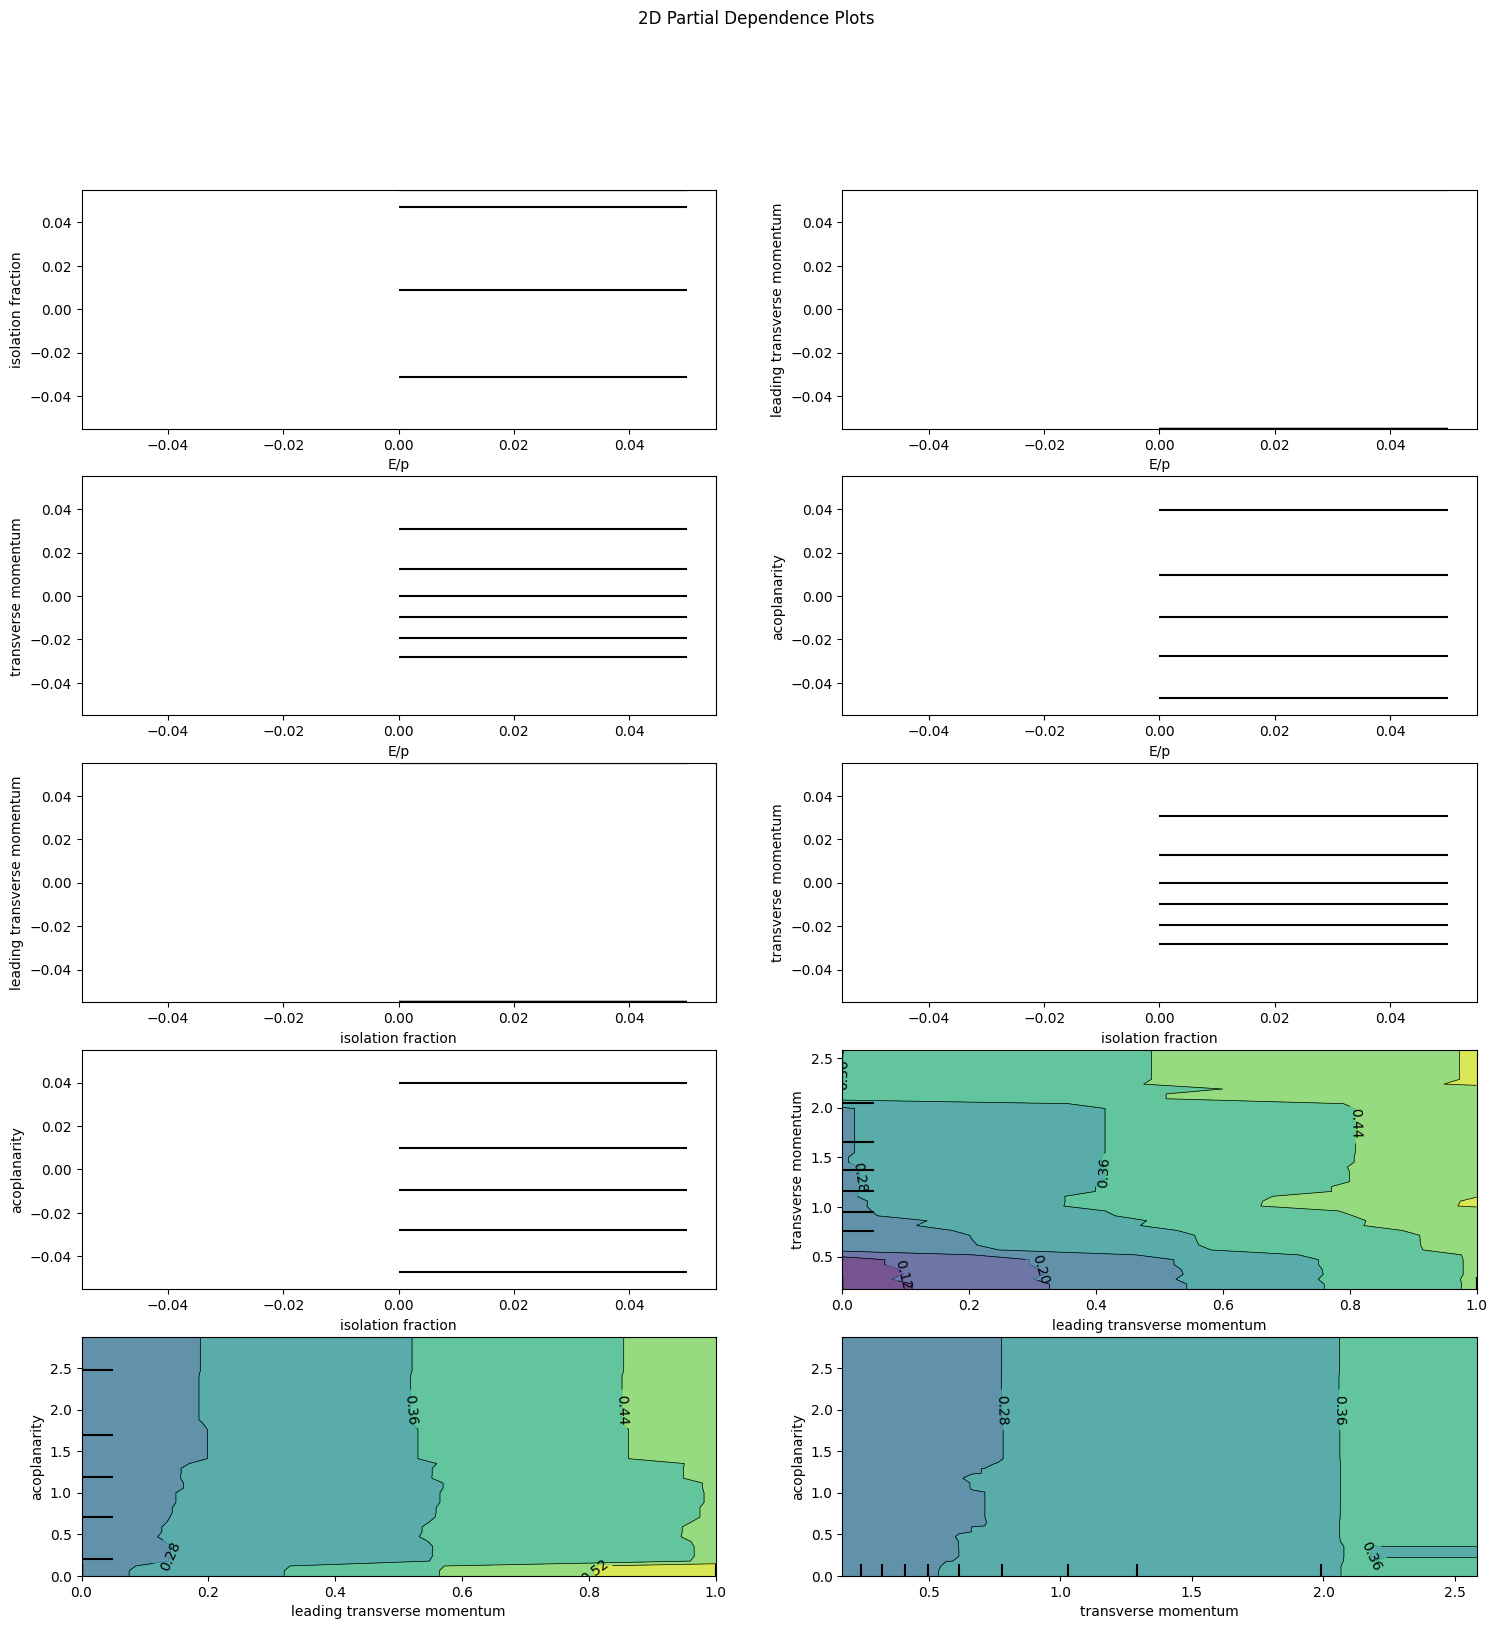

In [50]:
pairs = [(0, 1), (0, 2), (0, 4), (0, 5), (1,2), (1, 4), (1, 5), (2, 4), (2, 5), (4, 5)]
fig, ax = plt.subplots(5, 2, figsize=(18, 18))
PartialDependenceDisplay.from_estimator(model, X_val, features=pairs, feature_names=feature_names, ax=ax, grid_resolution=50, kind="average")
plt.suptitle("2D Partial Dependence Plots")
plt.show()

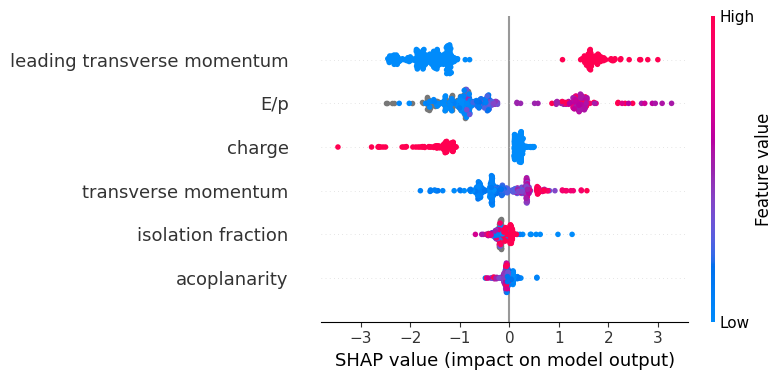

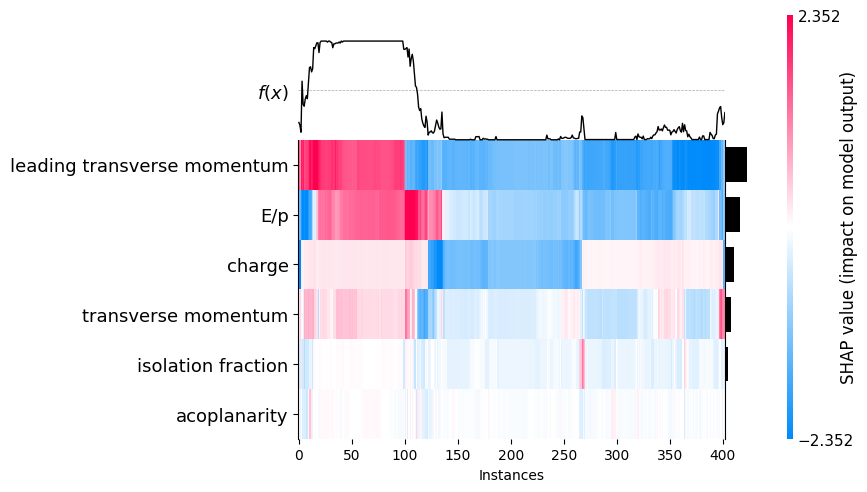

<Axes: xlabel='Instances'>

In [51]:
import shap

X_val_sample = shap.sample(X_val, 1000, random_state=42) 
explainer = shap.TreeExplainer(model)
shap_values_explanation = explainer(X_val_sample)
shap_values_explanation.feature_names = feature_names

shap.summary_plot(shap_values_explanation, X_val_sample, feature_names=feature_names)
shap.plots.heatmap(shap_values_explanation)


Maximum F1 Score: 0.9490
Optimal Threshold: 0.8561


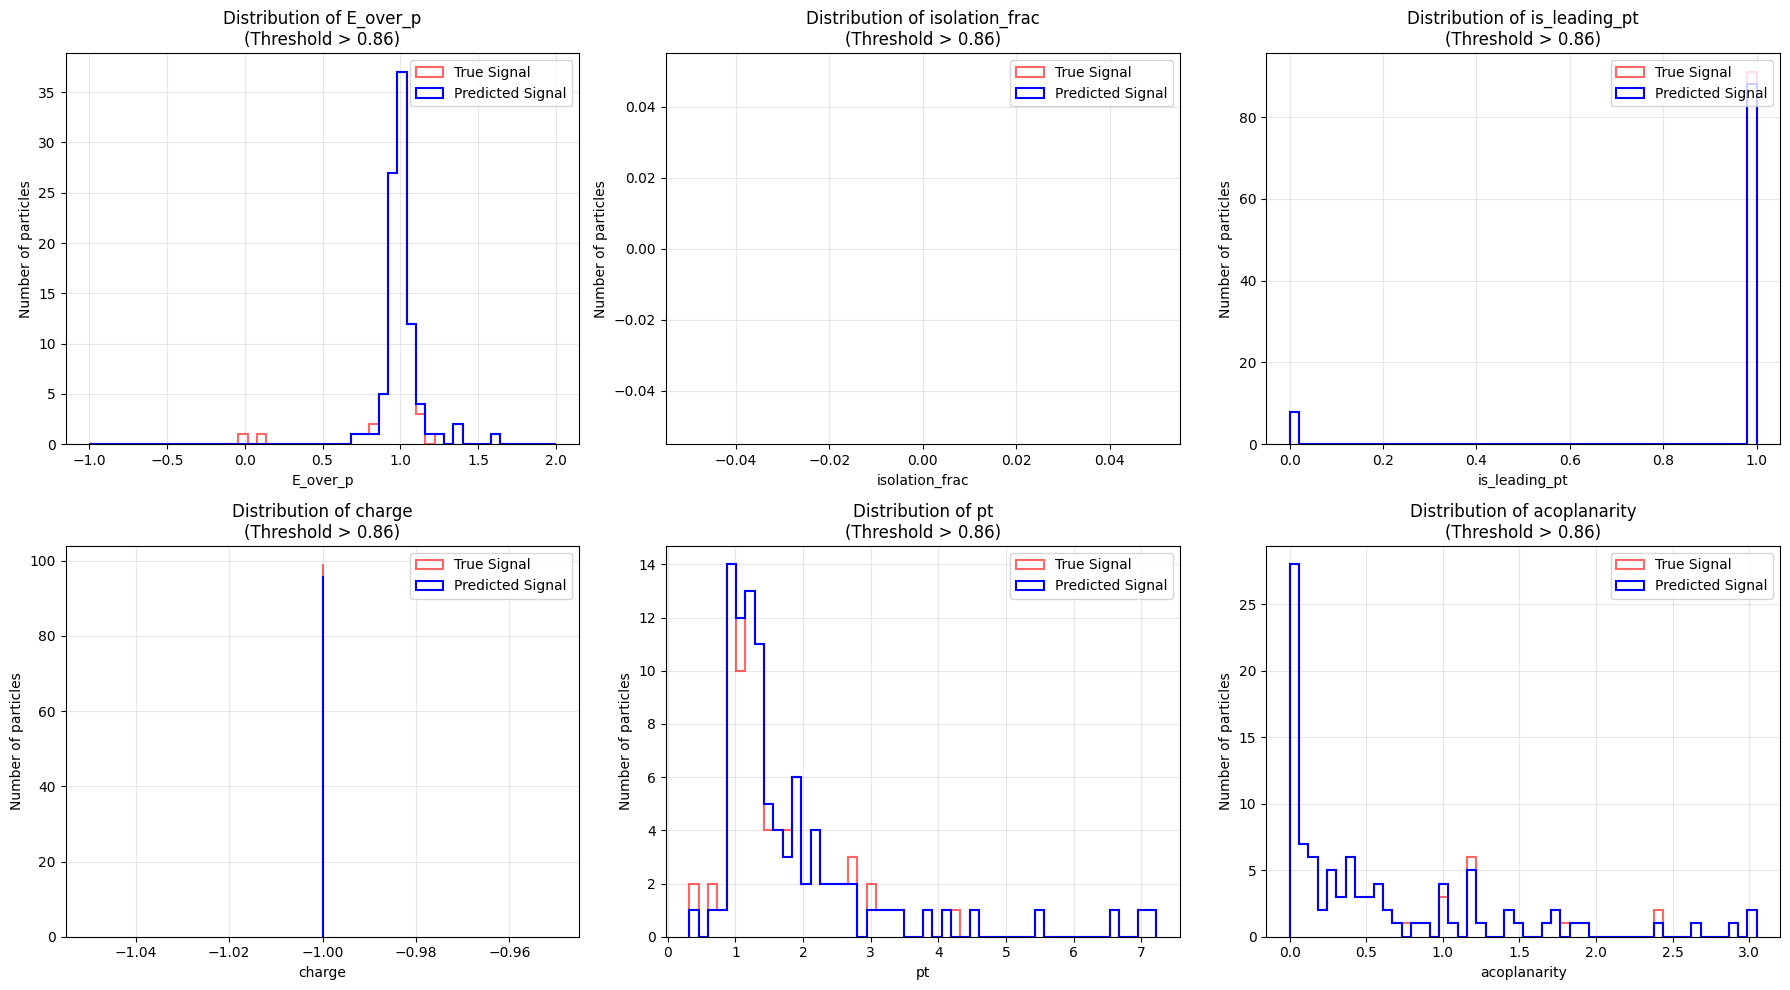

In [52]:
precisions, recalls, thresholds = precision_recall_curve(y_val, val_pred_sklearn) # precision = purity, recall = efficiency

precisions = precisions[:-1] # for array alignment since sklearn precision recall returns an extra point
recalls = recalls[:-1]

f1_scores = 2 * (precisions * recalls) / (precisions + recalls) # calculates F1 score for each threshold

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] # best threshold is the one that gives the highest F1 score, which balances purity and efficiency
best_f1 = f1_scores[best_idx] # best f1 score

print(f"Maximum F1 Score: {best_f1:.4f}")
print(f"Optimal Threshold: {best_threshold:.4f}")

# recompute efficiency/purity vs Bjorken variables using best threshold
evaluation_results = efficiency_purity_vs_bjorken(val_pred_sklearn, y_val, event_info_val, threshold=best_threshold)
bin_centers_Q2, efficiencies_Q2, purities_Q2, bin_centers_x, efficiencies_x, purities_x, bin_centers_y, efficiencies_y, purities_y, true_electrons_per_bin_Q2, true_electrons_per_bin_x, true_electrons_per_bin_y = evaluation_results

predicted_signal_mask = (val_pred_sklearn > best_threshold) # now use said threshold
X_val_predicted_signal = X_val[predicted_signal_mask]

feature_names = ["E_over_p", "isolation_frac", "is_leading_pt", "charge", "pt", "acoplanarity"]
# Custom plot ranges for specific features (min, max)
plot_ranges = {"E_over_p": (-1, 2)}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    true_signal_mask = (y_val == 1)

    if feature in plot_ranges:
        lo, hi = plot_ranges[feature]
        shared_bins = np.linspace(lo, hi, 51)
    else:
        # shared bin edges so both histograms align exactly
        all_vals = np.concatenate([X_val[true_signal_mask][:, i], X_val_predicted_signal[:, i]])
    
        shared_bins = np.linspace(all_vals.min(), all_vals.max(), 51)

    # plots the actual signal distribution in the validation set for comparison
    axes[i].hist(X_val[true_signal_mask][:, i], bins=shared_bins, histtype='step', color='red', linewidth=1.5, alpha=0.6, label='True Signal')

    # the distribution of the predicted signal
    axes[i].hist(X_val_predicted_signal[:, i], bins=shared_bins, histtype='step', color='blue', linewidth=1.5, label='Predicted Signal')
    
    axes[i].set_title(f'Distribution of {feature}\n(Threshold > {best_threshold:.2f})')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Number of particles')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

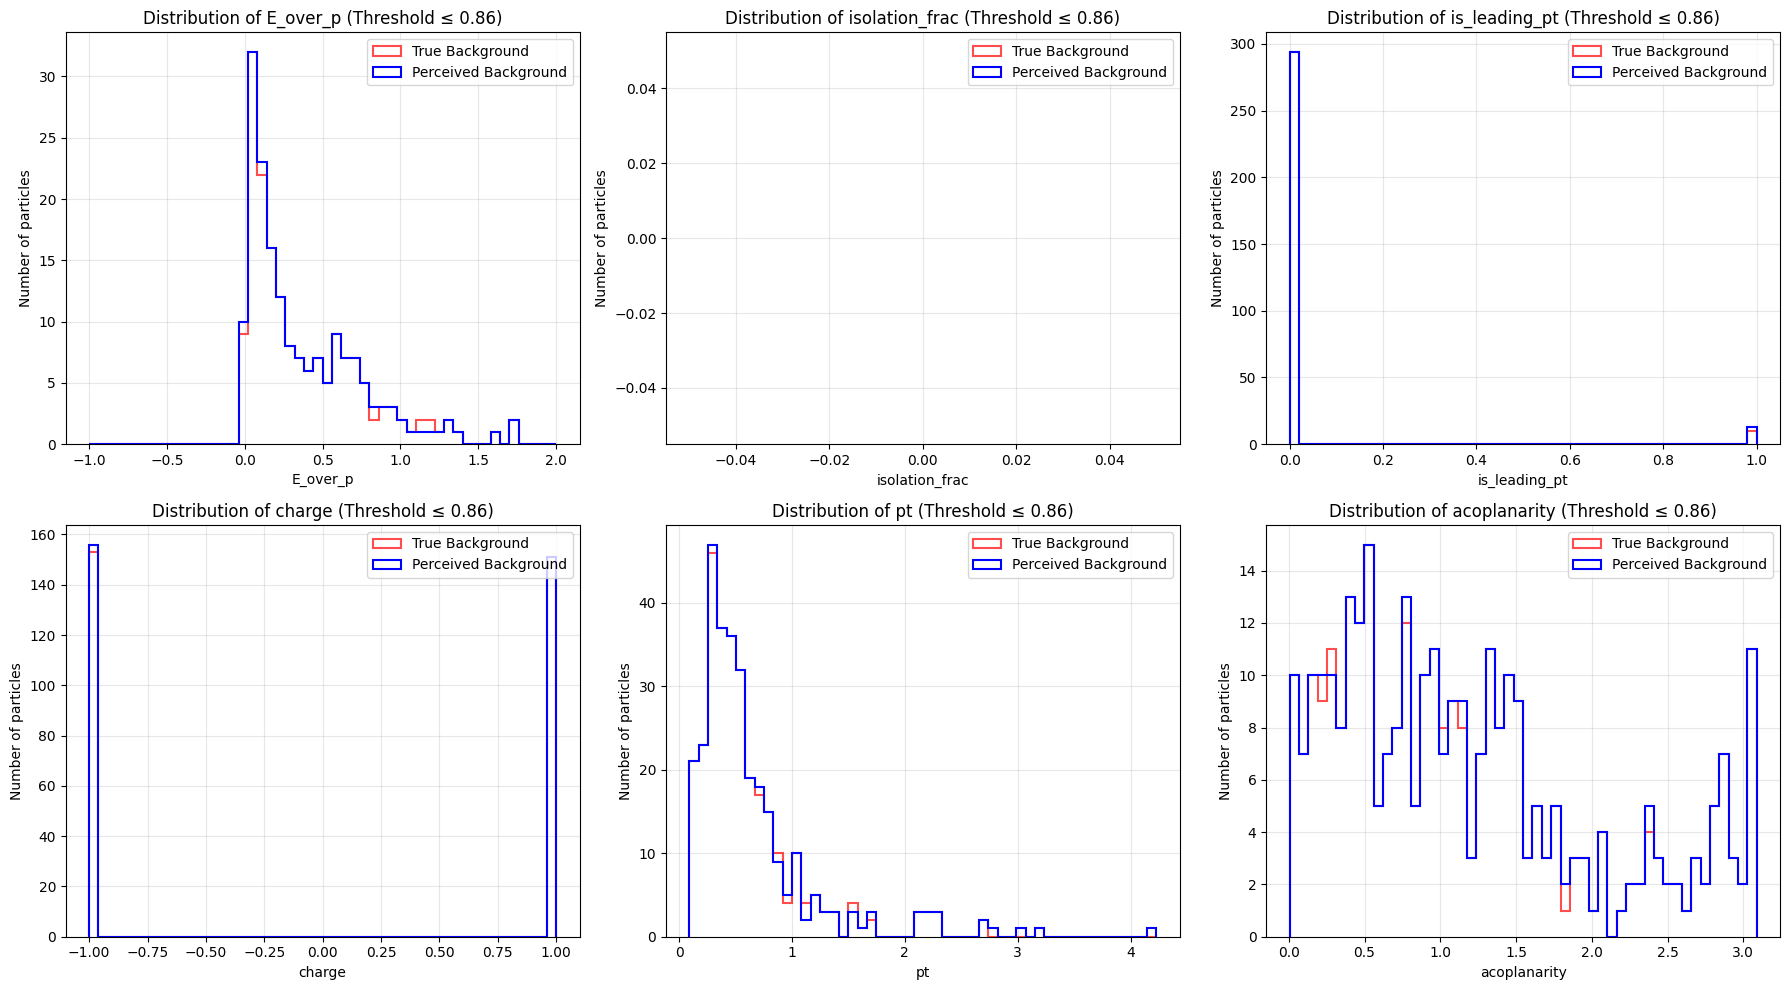

In [53]:
# true background vs perceived background distributions for input variables
# perceived background = particles classified as background by the chosen threshold

true_background_mask = (y_val == 0)
predicted_background_mask = (val_pred_sklearn <= best_threshold)
X_val_predicted_background = X_val[predicted_background_mask]

feature_names = ["E_over_p", "isolation_frac", "is_leading_pt", "charge", "pt", "acoplanarity"]
# Custom plot ranges for specific features (min, max)
plot_ranges = {"E_over_p": (-1, 2)}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    if feature in plot_ranges:
        lo, hi = plot_ranges[feature]
        shared_bins = np.linspace(lo, hi, 51)
    else:
        # shared bin edges so both histograms align exactly
        all_vals = np.concatenate([X_val[true_background_mask][:, i], X_val_predicted_background[:, i]])
        shared_bins = np.linspace(all_vals.min(), all_vals.max(), 51)

    # true background distribution in validation set
    axes[i].hist(
        X_val[true_background_mask][:, i],
        bins=shared_bins,
        histtype='step',
        color='red',
        linewidth=1.5,
        alpha=0.7,
        label='True Background'
    )

    # perceived/predicted background distribution
    axes[i].hist(
        X_val_predicted_background[:, i],
        bins=shared_bins,
        histtype='step',
        color='blue',
        linewidth=1.5,
        label='Perceived Background'
    )

    axes[i].set_title(f'Distribution of {feature} (Threshold ≤ {best_threshold:.2f})')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Number of particles')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

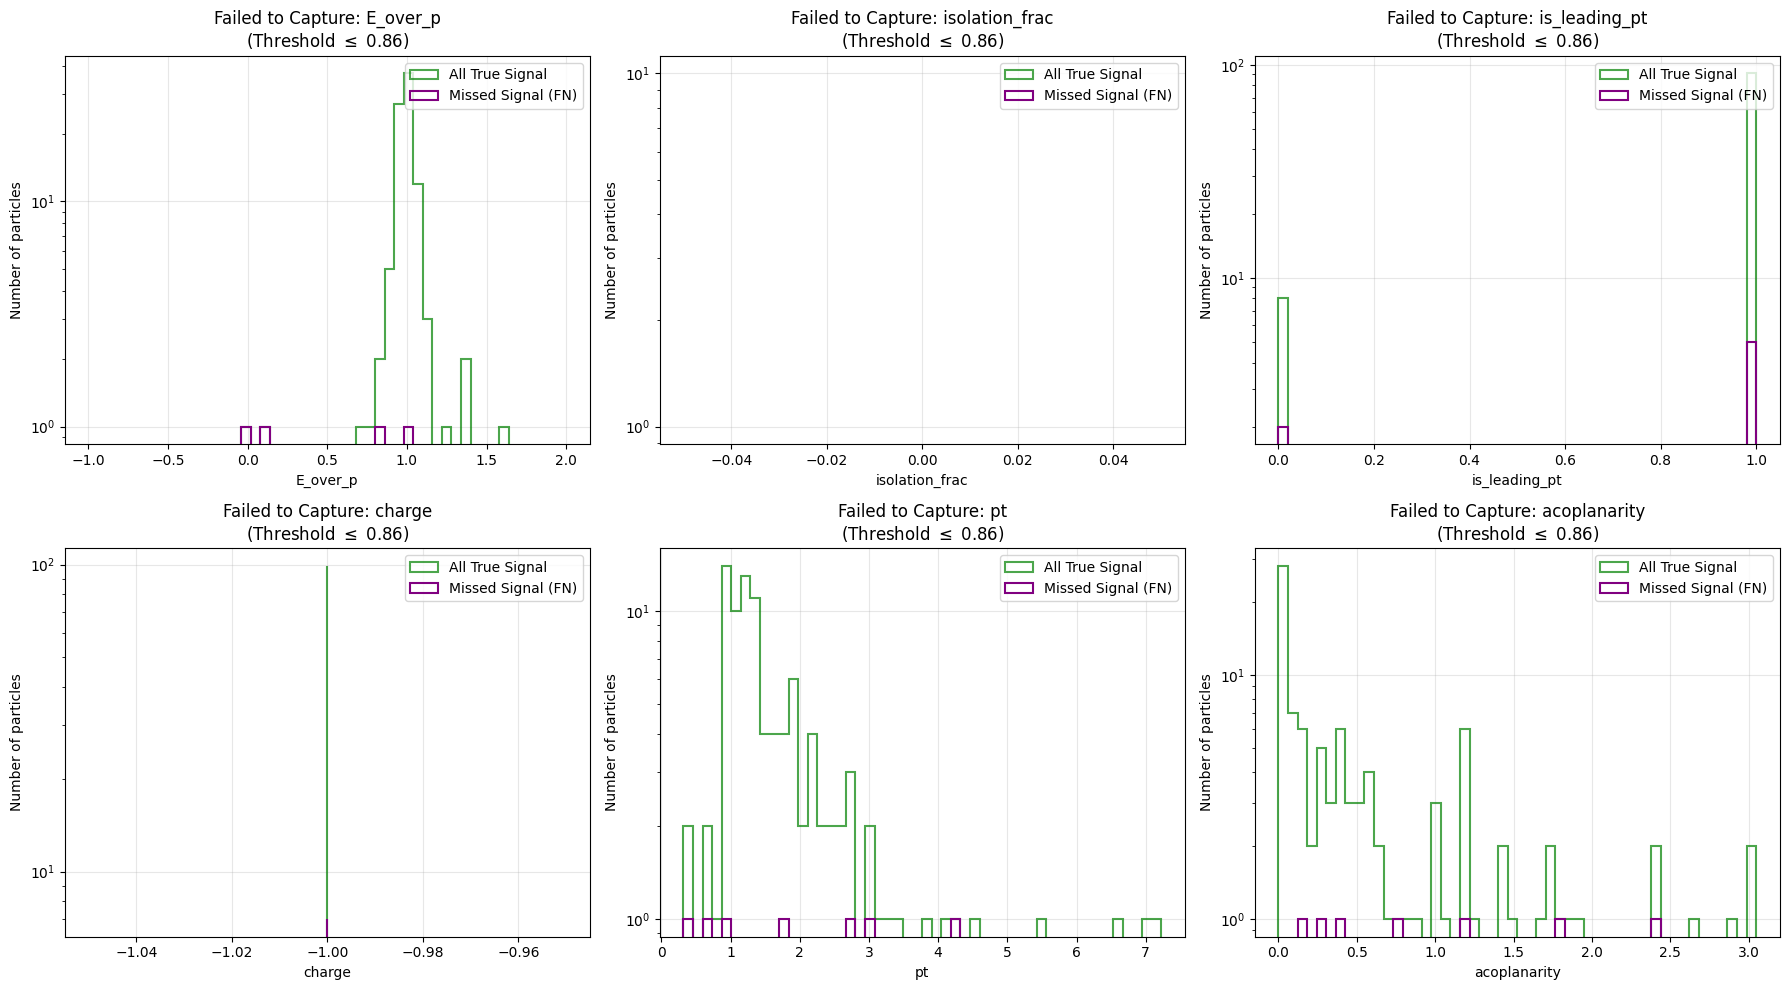

In [54]:
true_signal_mask = (y_val == 1)
predicted_background_mask = (val_pred_sklearn <= best_threshold)

missed_signal_mask = true_signal_mask & predicted_background_mask

X_val_true_signal = X_val[true_signal_mask]
X_val_missed_signal = X_val[missed_signal_mask]

feature_names = ["E_over_p", "isolation_frac", "is_leading_pt", "charge", "pt", "acoplanarity"]
# Custom plot ranges for specific features (min, max)
plot_ranges = {"E_over_p": (-1, 2)}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    if feature in plot_ranges:
        lo, hi = plot_ranges[feature]
        shared_bins = np.linspace(lo, hi, 51)
    else:
        # Create shared bin edges so both histograms align exactly based on the data present
        all_vals = np.concatenate([X_val_true_signal[:, i], X_val_missed_signal[:, i]])
        shared_bins = np.linspace(all_vals.min(), all_vals.max(), 51)

    # all true signal electrons
    axes[i].hist(
        X_val_true_signal[:, i],
        bins=shared_bins,
        histtype='step',
        color='green',
        linewidth=1.5,
        alpha=0.7,
        label='All True Signal'
    )

    # missed signal distribution (false negatives)
    axes[i].hist(
        X_val_missed_signal[:, i],
        bins=shared_bins,
        histtype='step',
        color='purple',
        linewidth=1.5,
        label='Missed Signal (FN)'
    )

    axes[i].set_title(f'Failed to Capture: {feature}\n(Threshold $\leq$ {best_threshold:.2f})')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Number of particles')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)
    
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

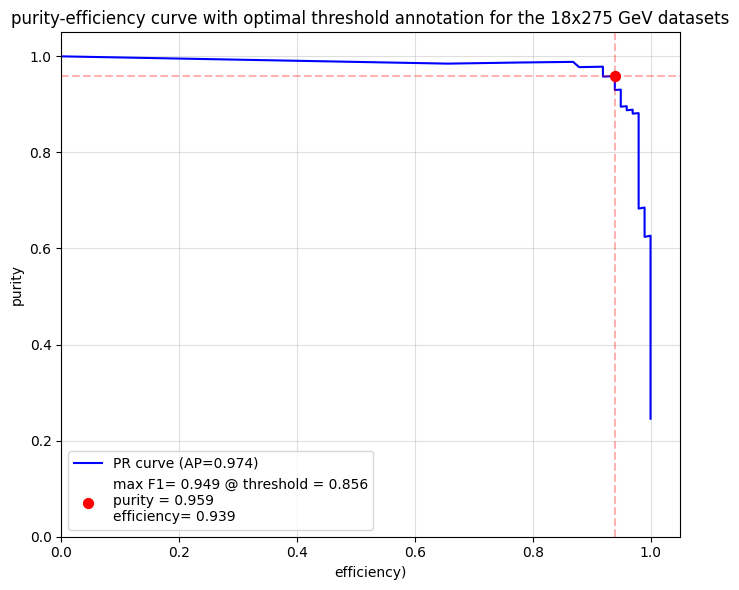

In [55]:
precisions_plot, recalls_plot, thresholds_plot = precision_recall_curve(y_val, val_pred_sklearn)
ap = average_precision_score(y_val, val_pred_sklearn)

# Find the point on the curve corresponding to the best F1 threshold
# (best_threshold was already computed earlier)
# Find the index in thresholds_plot closest to best_threshold
best_thresh_idx = np.argmin(np.abs(thresholds_plot - best_threshold))
best_precision = precisions_plot[best_thresh_idx]
best_recall = recalls_plot[best_thresh_idx]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recalls_plot, precisions_plot, color='blue', lw=1.5, label=f'PR curve (AP={ap:.3f})')
ax.scatter(best_recall, best_precision, color='red', s=50, zorder=5,
           label=f'max F1= {best_f1:.3f} @ threshold = {best_threshold:.3f}\n'
                 f'purity = {best_precision:.3f}\n'
                 f'efficiency= {best_recall:.3f}')
ax.axhline(best_precision, color='red', ls='--', alpha=0.3)
ax.axvline(best_recall, color='red', ls='--', alpha=0.3)
ax.set_xlabel('efficiency)')
ax.set_ylabel('purity')
ax.set_title('purity-efficiency curve with optimal threshold annotation for the 18x275 GeV datasets')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.4)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [56]:
# Define the interesting regions for each configuration
regions_18x275 = {
    "low x (x < 1e-3)":    lambda df: df['x'].values < 1e-3,
    "high Q2 (Q2 > 100)":  lambda df: df['Q2'].values > 100,
    "high y (y > 0.7)":    lambda df: df['y'].values > 0.7,
}

regions_5x41 = {
    "high x (x > 0.1)":    lambda df: df['x'].values > 0.1,
    "low Q2 (Q2 < 5)":     lambda df: df['Q2'].values < 5,
    "high y (y > 0.7)":    lambda df: df['y'].values > 0.7,
}

# ...existing code...

# Example: print AP and efficiency/purity at best threshold for each region
from sklearn.metrics import average_precision_score

for name, cut in regions_5x41.items():  # swap to regions_18x275 for the other dataset
    mask = cut(event_info_val).values if hasattr(cut(event_info_val), 'values') else cut(event_info_val)
    mask = np.asarray(mask)  # ensure it's a plain numpy boolean array
    n_sig = y_val[mask].sum()
    n_tot = mask.sum()
    if n_sig < 5:
        print(f"{name}: too few signal ({n_sig}), skipping")
        continue
    
    ap = average_precision_score(y_val[mask], val_pred_sklearn[mask])
    
    pred = val_pred_sklearn[mask] > best_threshold
    tp = ((y_val[mask] == 1) & pred).sum()
    fp = ((y_val[mask] == 0) & pred).sum()
    fn = ((y_val[mask] == 1) & ~pred).sum()
    
    eff = tp / (tp + fn) if (tp + fn) > 0 else 0
    pur = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"{name:30s}  AP={ap:.4f}  eff={eff:.4f}  pur={pur:.4f}  "
          f"(signal={n_sig}, total={n_tot})")

high x (x > 0.1)                AP=1.0000  eff=1.0000  pur=1.0000  (signal=24, total=31)
low Q2 (Q2 < 5)                 AP=0.9795  eff=0.9855  pur=0.9714  (signal=69, total=217)
high y (y > 0.7): too few signal (3), skipping


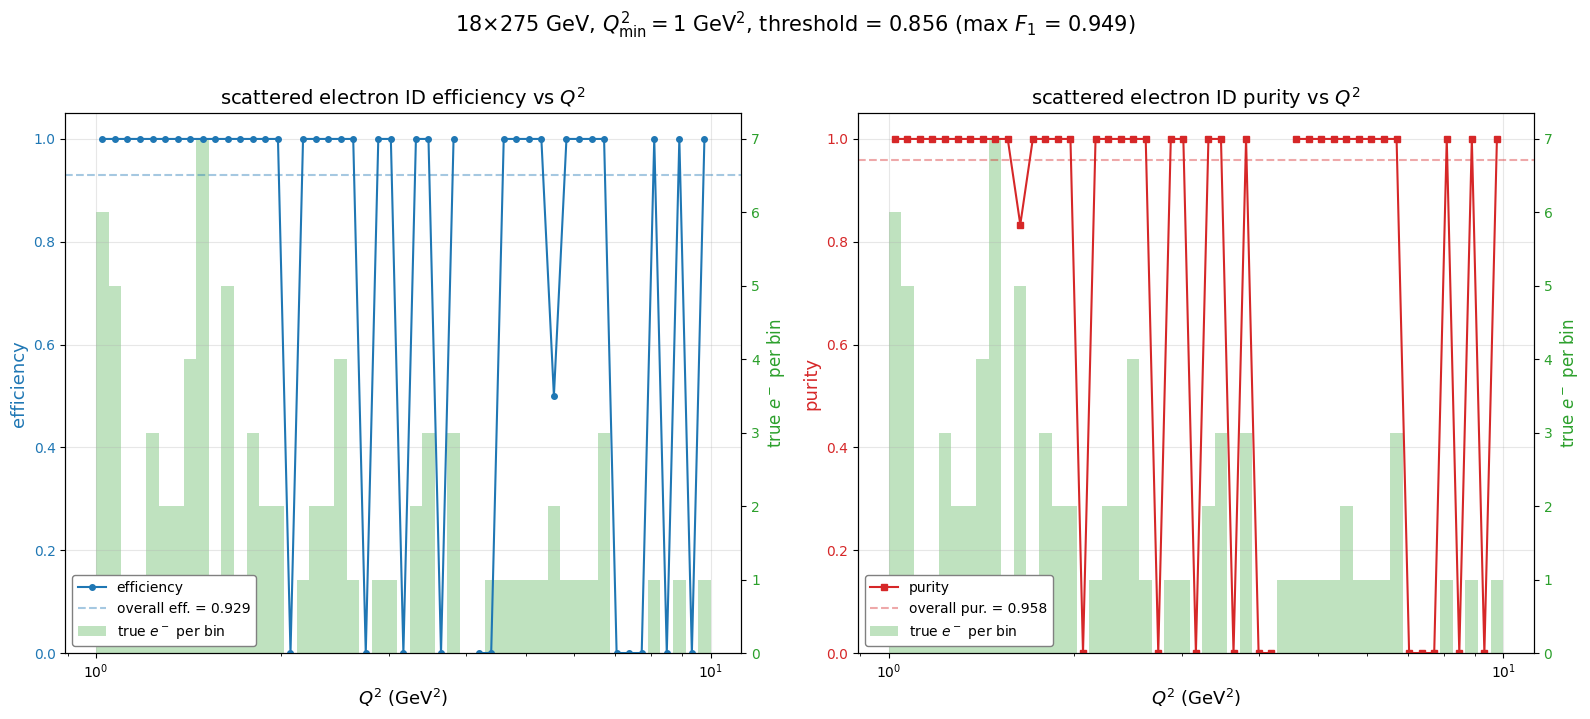

In [57]:
# --- Efficiency and Purity vs Q2 ---

Q2_bins = np.geomspace(1, 10, num=50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

color_eff = 'tab:blue'
color_count = 'tab:green'

ax1.plot(bin_centers_Q2, efficiencies_Q2, marker='o', markersize=4, color=color_eff, linewidth=1.5, label='efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('$Q^2$ (GeV$^2$)', fontsize=13)
ax1.set_ylabel('efficiency', fontsize=13, color=color_eff)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y', labelcolor=color_eff)
ax1.grid(True, alpha=0.3)

total_tp = np.sum((y_val == 1) & (val_pred_sklearn > best_threshold))
total_fn = np.sum((y_val == 1) & (val_pred_sklearn <= best_threshold))
overall_eff = total_tp / (total_tp + total_fn)
ax1.axhline(overall_eff, color=color_eff, ls='--', alpha=0.4, label=f'overall eff. = {overall_eff:.3f}')

ax1_twin = ax1.twinx()
ax1_twin.stairs(true_electrons_per_bin_Q2, Q2_bins, color=color_count, alpha=0.3, fill=True, label='true $e^-$ per bin')
ax1_twin.set_ylabel('true $e^-$ per bin', fontsize=12, color=color_count)
ax1_twin.tick_params(axis='y', labelcolor=color_count)

ax1.set_title('scattered electron ID efficiency vs $Q^2$', fontsize=14)
ax1.set_zorder(ax1_twin.get_zorder() + 1)
ax1.patch.set_visible(False)  # make the main axes background transparent so the twin shows through

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
legend1 = ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10,
                      framealpha=1.0, edgecolor='gray', facecolor='white')
legend1.set_zorder(10)

color_pur = 'tab:red'

ax2.plot(bin_centers_Q2, purities_Q2, marker='s', markersize=4, color=color_pur, linewidth=1.5, label='purity')
ax2.set_xscale('log')
ax2.set_xlabel('$Q^2$ (GeV$^2$)', fontsize=13)
ax2.set_ylabel('purity', fontsize=13, color=color_pur)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor=color_pur)
ax2.grid(True, alpha=0.3)

total_fp = np.sum((y_val == 0) & (val_pred_sklearn > best_threshold))
overall_pur = total_tp / (total_tp + total_fp)
ax2.axhline(overall_pur, color=color_pur, ls='--', alpha=0.4, label=f'overall pur. = {overall_pur:.3f}')

ax2_twin = ax2.twinx()
ax2_twin.stairs(true_electrons_per_bin_Q2, Q2_bins, color=color_count, alpha=0.3, fill=True, label='true $e^-$ per bin')
ax2_twin.set_ylabel('true $e^-$ per bin', fontsize=12, color=color_count)
ax2_twin.tick_params(axis='y', labelcolor=color_count)

ax2.set_title('scattered electron ID purity vs $Q^2$', fontsize=14)

ax2.set_zorder(ax2_twin.get_zorder() + 1)
ax2.patch.set_visible(False)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
legend2 = ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10,
                      framealpha=1.0, edgecolor='gray', facecolor='white')
legend2.set_zorder(10)

fig.suptitle('18×275 GeV, $Q^2_{\\mathrm{min}} = 1$ GeV$^2$, threshold = ' + f'{best_threshold:.3f} (max $F_1$ = {best_f1:.3f})', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

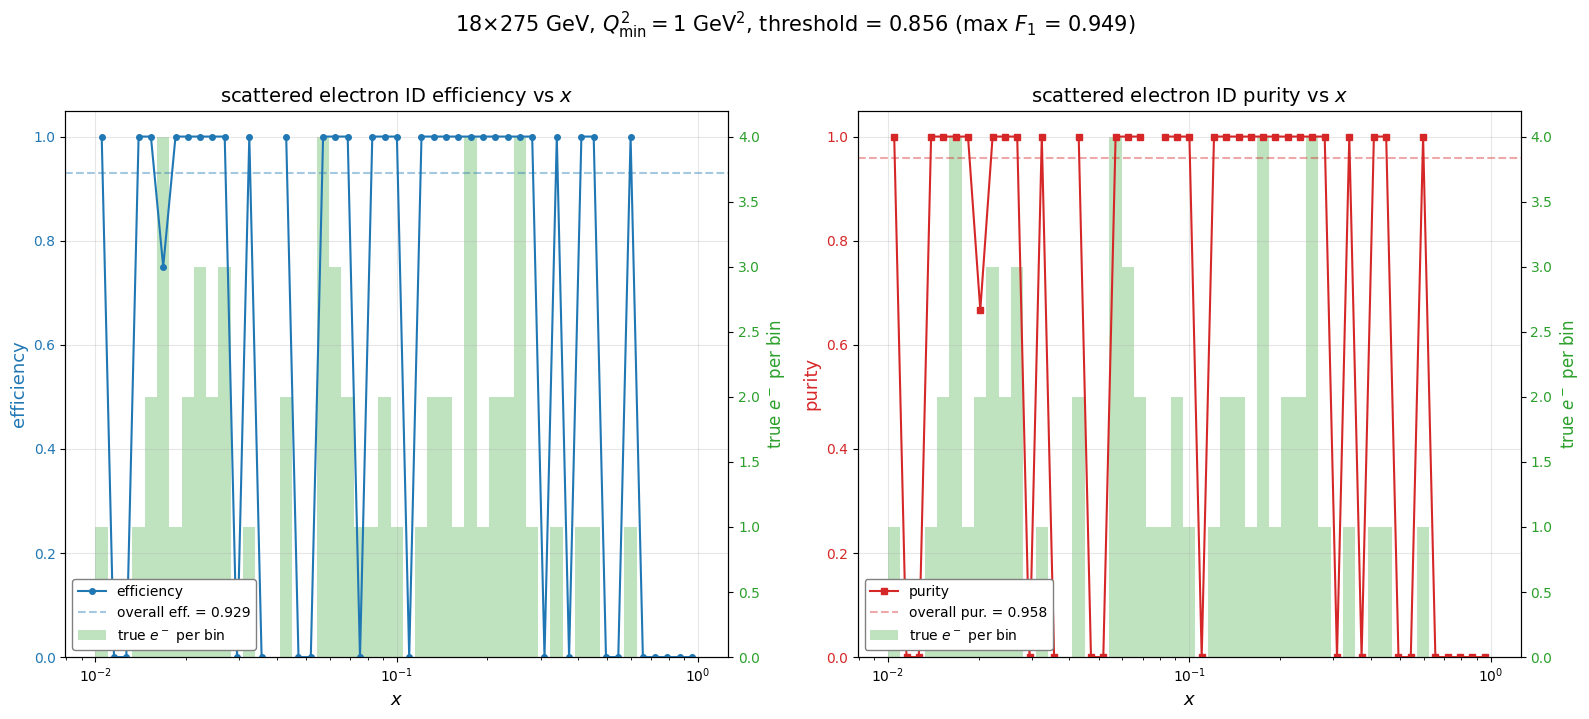

In [58]:
# --- Efficiency and Purity vs x ---

x_bins = np.geomspace(1e-2, 1, num=50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

color_eff = 'tab:blue'
color_count = 'tab:green'

ax1.plot(bin_centers_x, efficiencies_x, marker='o', markersize=4, color=color_eff, linewidth=1.5, label='efficiency')
ax1.set_xscale('log')
ax1.set_xlabel('$x$', fontsize=13)
ax1.set_ylabel('efficiency', fontsize=13, color=color_eff)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y', labelcolor=color_eff)
ax1.grid(True, alpha=0.3)

ax1.axhline(overall_eff, color=color_eff, ls='--', alpha=0.4, label=f'overall eff. = {overall_eff:.3f}')

ax1_twin = ax1.twinx()
ax1_twin.stairs(true_electrons_per_bin_x, x_bins, color=color_count, alpha=0.3, fill=True, label='true $e^-$ per bin')
ax1_twin.set_ylabel('true $e^-$ per bin', fontsize=12, color=color_count)
ax1_twin.tick_params(axis='y', labelcolor=color_count)

ax1.set_title('scattered electron ID efficiency vs $x$', fontsize=14)
ax1.set_zorder(ax1_twin.get_zorder() + 1)
ax1.patch.set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
legend1 = ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10,
                      framealpha=1.0, edgecolor='gray', facecolor='white')
legend1.set_zorder(10)

color_pur = 'tab:red'

ax2.plot(bin_centers_x, purities_x, marker='s', markersize=4, color=color_pur, linewidth=1.5, label='purity')
ax2.set_xscale('log')
ax2.set_xlabel('$x$', fontsize=13)
ax2.set_ylabel('purity', fontsize=13, color=color_pur)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor=color_pur)
ax2.grid(True, alpha=0.3)

ax2.axhline(overall_pur, color=color_pur, ls='--', alpha=0.4, label=f'overall pur. = {overall_pur:.3f}')

ax2_twin = ax2.twinx()
ax2_twin.stairs(true_electrons_per_bin_x, x_bins, color=color_count, alpha=0.3, fill=True, label='true $e^-$ per bin')
ax2_twin.set_ylabel('true $e^-$ per bin', fontsize=12, color=color_count)
ax2_twin.tick_params(axis='y', labelcolor=color_count)

ax2.set_title('scattered electron ID purity vs $x$', fontsize=14)

ax2.set_zorder(ax2_twin.get_zorder() + 1)
ax2.patch.set_visible(False)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
legend2 = ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10,
                      framealpha=1.0, edgecolor='gray', facecolor='white')
legend2.set_zorder(10)

fig.suptitle('18×275 GeV, $Q^2_{\\mathrm{min}} = 1$ GeV$^2$, threshold = ' + f'{best_threshold:.3f} (max $F_1$ = {best_f1:.3f})', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### **2D efficiency and purity in $Q^{2}$-$x$ space**

This section builds 2D maps in $(Q^2, x)$ bins using the validation sample and the chosen classifier threshold.

In [59]:
def efficiency_purity_2d_q2x(val_pred, y_true, event_info, threshold=0.5,
                             q2_bins=None, x_bins=None, min_denom=1):
    if q2_bins is None:
        q2_bins = np.geomspace(1.0, 1e4, 26)
    if x_bins is None:
        x_bins = np.geomspace(1e-4, 1.0, 26)

    q2_vals = np.asarray(event_info["Q2"].values, dtype=float)
    x_vals = np.asarray(event_info["x"].values, dtype=float)
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(val_pred) > threshold

    n_q2 = len(q2_bins) - 1
    n_x = len(x_bins) - 1

    eff_map = np.full((n_q2, n_x), np.nan, dtype=float)
    pur_map = np.full((n_q2, n_x), np.nan, dtype=float)
    n_sig_map = np.zeros((n_q2, n_x), dtype=int)
    n_pred_map = np.zeros((n_q2, n_x), dtype=int)
    n_tot_map = np.zeros((n_q2, n_x), dtype=int)

    for iq in range(n_q2):
        q2_lo, q2_hi = q2_bins[iq], q2_bins[iq + 1]
        q2_mask = (q2_vals >= q2_lo) & (q2_vals < q2_hi)

        for ix in range(n_x):
            x_lo, x_hi = x_bins[ix], x_bins[ix + 1]
            in_bin = q2_mask & (x_vals >= x_lo) & (x_vals < x_hi)

            if not np.any(in_bin):
                continue

            yb = y_true[in_bin]
            pb = y_pred[in_bin]

            tp = np.sum((yb == 1) & (pb == 1))
            fp = np.sum((yb == 0) & (pb == 1))
            fn = np.sum((yb == 1) & (pb == 0))

            n_sig = tp + fn
            n_pred = tp + fp

            n_sig_map[iq, ix] = n_sig
            n_pred_map[iq, ix] = n_pred
            n_tot_map[iq, ix] = np.sum(in_bin)

            if n_sig >= min_denom:
                eff_map[iq, ix] = tp / n_sig
            if n_pred >= min_denom:
                pur_map[iq, ix] = tp / n_pred

    return {
        "q2_bins": q2_bins,
        "x_bins": x_bins,
        "efficiency": eff_map,
        "purity": pur_map,
        "n_signal": n_sig_map,
        "n_predicted_signal": n_pred_map,
        "n_total": n_tot_map,
    }

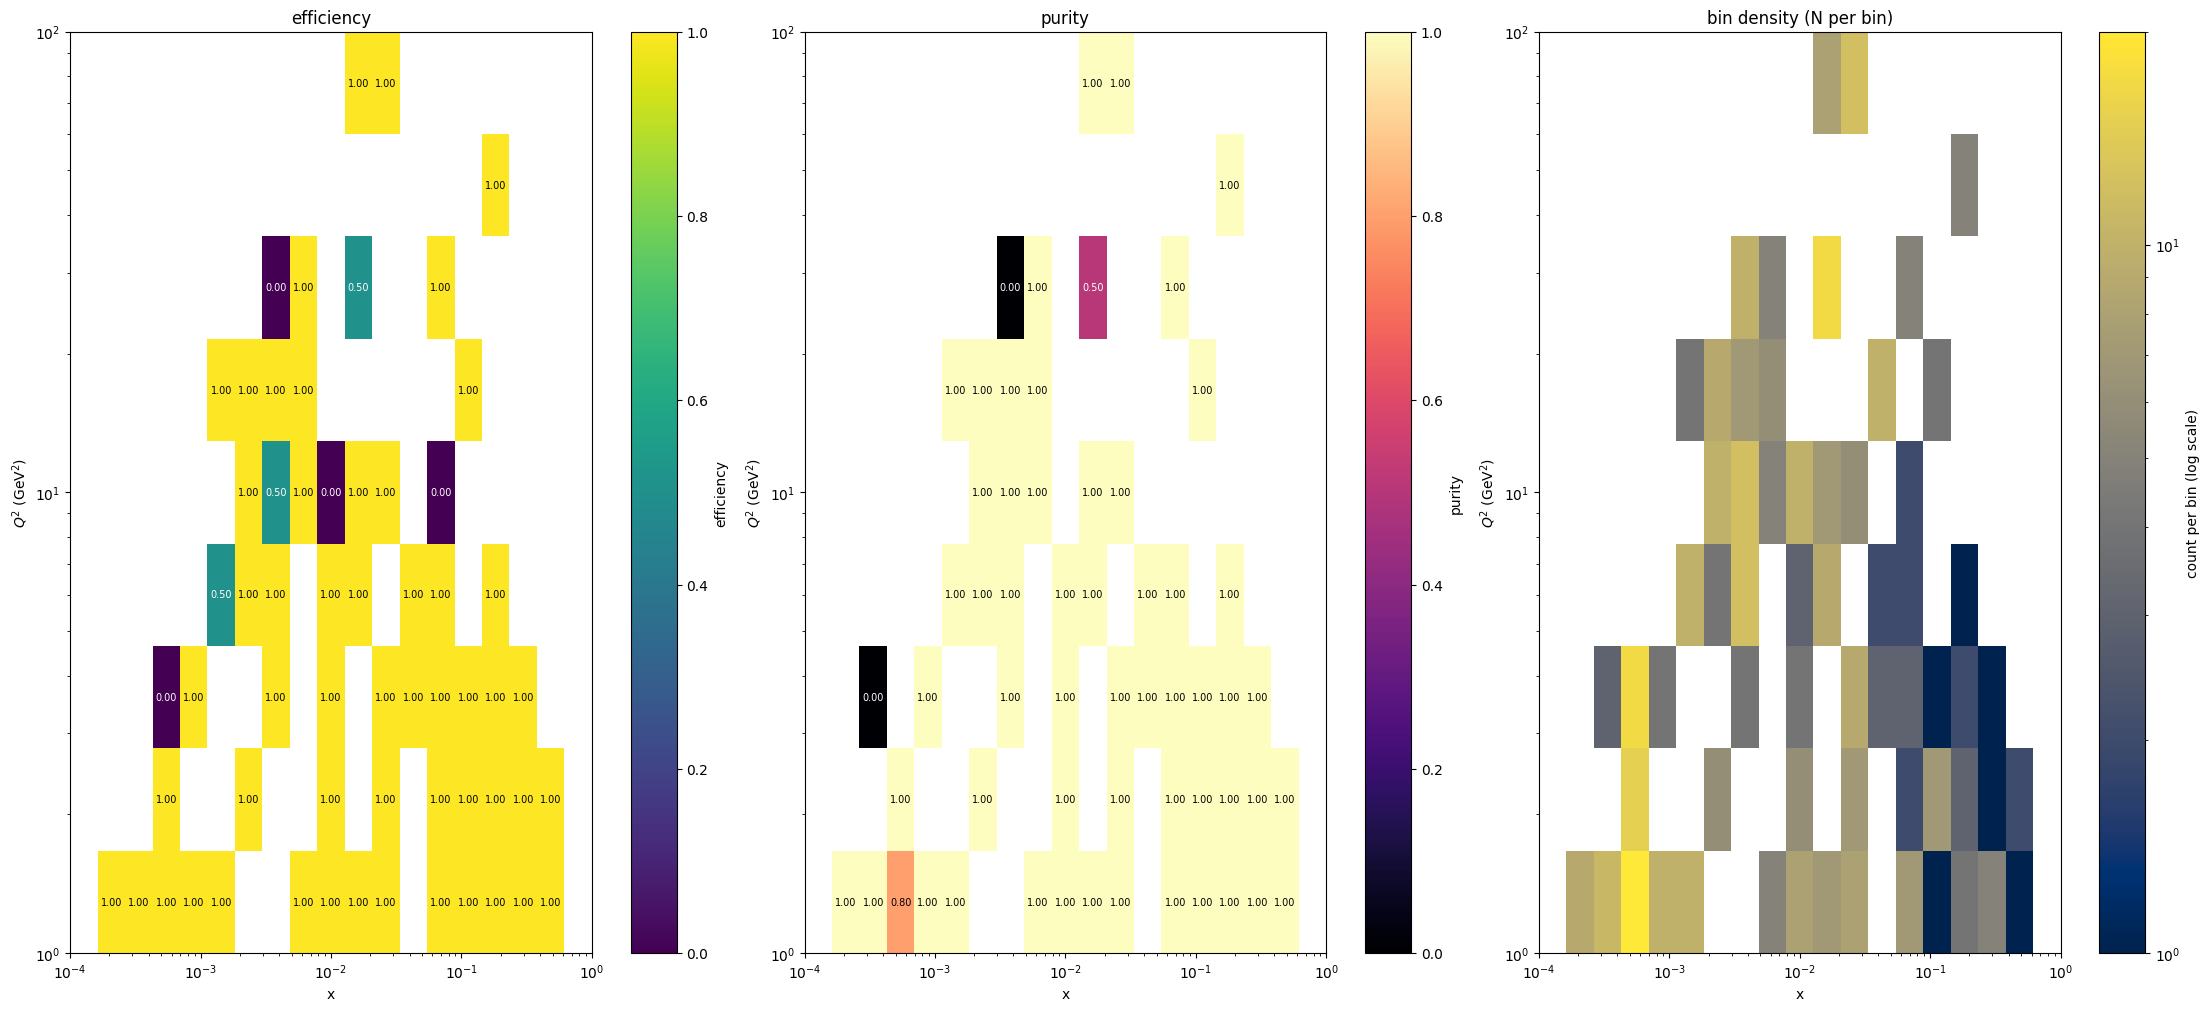

Coarser grid bins: 9 x 19
Non-empty coarse bins: 62


In [60]:
# Comparison (coarser bins): efficiency + purity labels, with bin-density panel
from matplotlib.colors import LogNorm

q2x_2d_coarse_density = efficiency_purity_2d_q2x(
    val_pred=val_pred_sklearn,
    y_true=y_val,
    event_info=event_info_val,
    threshold=best_threshold,
    q2_bins=np.geomspace(1.0, 100, 10),
    x_bins=np.geomspace(1e-4, 1.0, 20),
    min_denom=1
)

q2_bins_cd = q2x_2d_coarse_density["q2_bins"]
x_bins_cd = q2x_2d_coarse_density["x_bins"]
eff_2d_cd = q2x_2d_coarse_density["efficiency"]
pur_2d_cd = q2x_2d_coarse_density["purity"]
n_tot_2d_cd = q2x_2d_coarse_density["n_total"]

q2_centers_cd = np.sqrt(q2_bins_cd[:-1] * q2_bins_cd[1:])
x_centers_cd = np.sqrt(x_bins_cd[:-1] * x_bins_cd[1:])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 10), constrained_layout=True)

m1 = ax1.pcolormesh(x_bins_cd, q2_bins_cd, eff_2d_cd, shading="auto", vmin=0.0, vmax=1.0, cmap="viridis")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("x")
ax1.set_ylabel(r"$Q^2$ (GeV$^2$)")
ax1.set_title("efficiency")
cb1 = fig.colorbar(m1, ax=ax1)
cb1.set_label("efficiency")

m2 = ax2.pcolormesh(x_bins_cd, q2_bins_cd, pur_2d_cd, shading="auto", vmin=0.0, vmax=1.0, cmap="magma")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("x")
ax2.set_ylabel(r"$Q^2$ (GeV$^2$)")
ax2.set_title("purity")
cb2 = fig.colorbar(m2, ax=ax2)
cb2.set_label("purity")

n_display_cd = np.where(n_tot_2d_cd > 0, n_tot_2d_cd, np.nan)
m3 = ax3.pcolormesh(
    x_bins_cd,
    q2_bins_cd,
    n_display_cd,
    shading="auto",
    cmap="cividis",
    norm=LogNorm(vmin=1, vmax=np.nanmax(n_display_cd))
)
ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlabel("x")
ax3.set_ylabel(r"$Q^2$ (GeV$^2$)")
ax3.set_title("bin density (N per bin)")
cb3 = fig.colorbar(m3, ax=ax3)
cb3.set_label("count per bin (log scale)")

# annotate only metric values (no N labels)
for iq, q2c in enumerate(q2_centers_cd):
    for ix, xc in enumerate(x_centers_cd):
        if n_tot_2d_cd[iq, ix] <= 0:
            continue

        eff_val = eff_2d_cd[iq, ix]
        pur_val = pur_2d_cd[iq, ix]

        if np.isfinite(eff_val):
            ax1.text(
                xc, q2c, f"{eff_val:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if eff_val < 0.55 else "black"
            )

        if np.isfinite(pur_val):
            ax2.text(
                xc, q2c, f"{pur_val:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if pur_val < 0.55 else "black"
            )

plt.show()

print(f"Coarser grid bins: {(len(q2_bins_cd)-1)} x {(len(x_bins_cd)-1)}")
print(f"Non-empty coarse bins: {np.sum(n_tot_2d_cd > 0)}")

In [61]:
stress_files = [
    "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5480.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5481.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5482.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5483.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5484.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5485.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5486.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5487.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5488.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5489.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5490.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5491.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5492.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5493.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5494.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5495.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5496.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5497.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5498.eicrecon.edm4eic.root",
    # "/home/user321/EIC-Project-25-26/arthur/projectxg/rootfiles/misc/stress/10x275/minQ2=1/pythia8NCDIS_10x275_minQ2=1_beamEffects_xAngle=-0.025_hiDiv_1.5499.eicrecon.edm4eic.root",
]

stress_trees = [uproot.open(f)["events"] for f in stress_files]

In [56]:
stress_filter_name=[
    "ReconstructedParticles/ReconstructedParticles.*",
    "MCParticles/MCParticles.*",
    "EcalBarrelClusters/EcalBarrelClusters.*",
    "EcalEndcapPClusters/EcalEndcapPClusters.*",
    "EcalEndcapNClusters/EcalEndcapNClusters.*",
    #"EcalBarrelClusterAssociations/EcalBarrelClusterAssociations.*",
    #"EcalEndcapPClusterAssociations/EcalEndcapPClusterAssociations.*",
    #"EcalEndcapNClusterAssociations/EcalEndcapNClusterAssociations.*",
    #"ReconstructedParticleAssociations/ReconstructedParticleAssociations.*",
    "InclusiveKinematicsTruth/InclusiveKinematicsTruth.*",
    "_ReconstructedParticleAssociations_*",
    "_EcalBarrelClusterAssociations_*",
    "_EcalEndcapNClusterAssociations_*",
    "_EcalEndcapPClusterAssociations_*",
]

stress_list = [tree.arrays(filter_name = stress_filter_name, library="ak") for tree in stress_trees]
stress_events = ak.concatenate(stress_list, axis=0)
[f for f in stress_events.fields if "Associations" in f]

['_EcalBarrelClusterAssociations_rec.index',
 '_EcalBarrelClusterAssociations_rec.collectionID',
 '_EcalBarrelClusterAssociations_sim.index',
 '_EcalBarrelClusterAssociations_sim.collectionID',
 '_EcalEndcapNClusterAssociations_rec.index',
 '_EcalEndcapNClusterAssociations_rec.collectionID',
 '_EcalEndcapNClusterAssociations_sim.index',
 '_EcalEndcapNClusterAssociations_sim.collectionID',
 '_EcalEndcapPClusterAssociations_rec.index',
 '_EcalEndcapPClusterAssociations_rec.collectionID',
 '_EcalEndcapPClusterAssociations_sim.index',
 '_EcalEndcapPClusterAssociations_sim.collectionID',
 '_ReconstructedParticleAssociations_rec.index',
 '_ReconstructedParticleAssociations_rec.collectionID',
 '_ReconstructedParticleAssociations_sim.index',
 '_ReconstructedParticleAssociations_sim.collectionID']

In [ ]:
# defining variables

# mc classification
S_mc_pdg = stress_events["MCParticles.PDG"]
S_mc_gen = stress_events["MCParticles.generatorStatus"]

# event-level truth
S_trueQ2 = stress_events["InclusiveKinematicsTruth.Q2"]
S_truex = stress_events["InclusiveKinematicsTruth.x"]
S_truey = stress_events["InclusiveKinematicsTruth.y"]

# track kinematics (raw from detector)
S_px_raw = stress_events["ReconstructedParticles.momentum.x"]
S_py_raw = stress_events["ReconstructedParticles.momentum.y"]
S_pz_raw = stress_events["ReconstructedParticles.momentum.z"]
S_charge = stress_events["ReconstructedParticles.charge"]
 
# boosting for event-level variables
S_massless_E = np.sqrt(S_px_raw**2 + S_py_raw**2 + S_pz_raw**2)

# cluster energies
S_barrel_E = stress_events["EcalBarrelClusters.energy"]
S_endcapP_E = stress_events["EcalEndcapPClusters.energy"]
S_endcapN_E = stress_events["EcalEndcapNClusters.energy"]

# calorimeter cluster positions (Cartesian, in mm)
S_barrel_pos_x  = stress_events["EcalBarrelClusters.position.x"]
S_barrel_pos_y  = stress_events["EcalBarrelClusters.position.y"]
S_barrel_pos_z  = stress_events["EcalBarrelClusters.position.z"]
S_endcapP_pos_x = stress_events["EcalEndcapPClusters.position.x"]
S_endcapP_pos_y = stress_events["EcalEndcapPClusters.position.y"]
S_endcapP_pos_z = stress_events["EcalEndcapPClusters.position.z"]
S_endcapN_pos_x = stress_events["EcalEndcapNClusters.position.x"]
S_endcapN_pos_y = stress_events["EcalEndcapNClusters.position.y"]
S_endcapN_pos_z = stress_events["EcalEndcapNClusters.position.z"]

vector.register_awkward()
S_reco_vec = vector.Array(ak.zip({
    "px": S_px_raw,
    "py": S_py_raw,
    "pz": S_pz_raw,
    "energy": np.sqrt(S_px_raw**2 + S_py_raw**2 + S_pz_raw**2 + mass**2)
}))

S_pt = S_reco_vec.pt
S_eta = S_reco_vec.eta
S_phi = S_reco_vec.phi
S_p = np.sqrt(S_px_raw**2 + S_py_raw**2 + S_pz_raw**2)

# mc matching using stress association branches
S_reco_to_mc_rec = stress_events["_ReconstructedParticleAssociations_rec.index"]
S_reco_to_mc_sim = stress_events["_ReconstructedParticleAssociations_sim.index"]

# cluster and MC associations (rec index is cluster index, sim index is MC particle index)
S_barrel_clu_idx = stress_events["_EcalBarrelClusterAssociations_rec.index"]
S_barrel_mc_idx = stress_events["_EcalBarrelClusterAssociations_sim.index"]

S_endcapN_clu_idx = stress_events["_EcalEndcapNClusterAssociations_rec.index"]
S_endcapN_mc_idx = stress_events["_EcalEndcapNClusterAssociations_sim.index"]

S_endcapP_clu_idx = stress_events["_EcalEndcapPClusterAssociations_rec.index"]
S_endcapP_mc_idx = stress_events["_EcalEndcapPClusterAssociations_sim.index"]

# boosted variables
Sboosted_px, Sboosted_py, Sboosted_pz, Sboosted_E = apply_boost(
    S_px_raw, S_py_raw, S_pz_raw, S_massless_E, P_tot, rot_y_angle, rot_x_angle
)

In [ ]:
# build stress-event features with the same inputs used for training

S_results_vectorised = [
    match_via_mc_vectorised(r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco)
    for r_rec, r_sim, bcl, bmc, bE, pcl, pmc, pE, ncl, nmc, nE, nreco in zip(
        S_reco_to_mc_rec, S_reco_to_mc_sim,
        S_barrel_clu_idx, S_barrel_mc_idx, S_barrel_E,
        S_endcapP_clu_idx, S_endcapP_mc_idx, S_endcapP_E,
        S_endcapN_clu_idx, S_endcapN_mc_idx, S_endcapN_E,
        ak.num(S_px_raw)
    )
]

S_barrel_E_per_reco_vec = ak.Array([r[0] for r in S_results_vectorised])
S_endcapN_E_per_reco_vec = ak.Array([r[1] for r in S_results_vectorised])
S_endcapP_E_per_reco_vec = ak.Array([r[2] for r in S_results_vectorised])

S_matched_calo_E_vec = ak.where(
    S_barrel_E_per_reco_vec > 0,
    S_barrel_E_per_reco_vec,
    ak.where(
        S_endcapN_E_per_reco_vec > 0,
        S_endcapN_E_per_reco_vec,
        ak.where(S_endcapP_E_per_reco_vec > 0, S_endcapP_E_per_reco_vec, 0.0)
    )
)

S_matched_E_over_p_vec = ak.where(
    (S_p > 0) & (S_charge != 0),
    S_matched_calo_E_vec / S_p,
    -1.0
)

S_barrel_eta_clu, S_barrel_phi_clu = xyz_to_eta_phi(S_barrel_pos_x, S_barrel_pos_y, S_barrel_pos_z)
S_endcapP_eta_clu, S_endcapP_phi_clu = xyz_to_eta_phi(S_endcapP_pos_x, S_endcapP_pos_y, S_endcapP_pos_z)
S_endcapN_eta_clu, S_endcapN_phi_clu = xyz_to_eta_phi(S_endcapN_pos_x, S_endcapN_pos_y, S_endcapN_pos_z)

S_all_calo_eta = ak.concatenate([S_barrel_eta_clu, S_endcapP_eta_clu, S_endcapN_eta_clu], axis=1)
S_all_calo_phi = ak.concatenate([S_barrel_phi_clu, S_endcapP_phi_clu, S_endcapN_phi_clu], axis=1)
S_all_calo_E = ak.concatenate([S_barrel_E, S_endcapP_E, S_endcapN_E], axis=1)

S_results_eta = [
    match_via_mc_vectorised(r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco)
    for r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco in zip(
        S_reco_to_mc_rec, S_reco_to_mc_sim,
        S_barrel_clu_idx, S_barrel_mc_idx, S_barrel_eta_clu,
        S_endcapP_clu_idx, S_endcapP_mc_idx, S_endcapP_eta_clu,
        S_endcapN_clu_idx, S_endcapN_mc_idx, S_endcapN_eta_clu,
        ak.num(S_px_raw)
    )
]
S_barrel_eta_per_part = ak.Array([r[0] for r in S_results_eta])
S_endcapN_eta_per_part = ak.Array([r[1] for r in S_results_eta])
S_endcapP_eta_per_part = ak.Array([r[2] for r in S_results_eta])

S_results_phi = [
    match_via_mc_vectorised(r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco)
    for r_rec, r_sim, bcl, bmc, bV, pcl, pmc, pV, ncl, nmc, nV, nreco in zip(
        S_reco_to_mc_rec, S_reco_to_mc_sim,
        S_barrel_clu_idx, S_barrel_mc_idx, S_barrel_phi_clu,
        S_endcapP_clu_idx, S_endcapP_mc_idx, S_endcapP_phi_clu,
        S_endcapN_clu_idx, S_endcapN_mc_idx, S_endcapN_phi_clu,
        ak.num(S_px_raw)
    )
]
S_barrel_phi_per_part = ak.Array([r[0] for r in S_results_phi])
S_endcapN_phi_per_part = ak.Array([r[1] for r in S_results_phi])
S_endcapP_phi_per_part = ak.Array([r[2] for r in S_results_phi])

S_matched_calo_eta = ak.where(
    S_barrel_E_per_reco_vec > 0,
    S_barrel_eta_per_part,
    ak.where(
        S_endcapN_E_per_reco_vec > 0,
        S_endcapN_eta_per_part,
        ak.where(S_endcapP_E_per_reco_vec > 0, S_endcapP_eta_per_part, 0.0)
    )
)

S_matched_calo_phi = ak.where(
    S_barrel_E_per_reco_vec > 0,
    S_barrel_phi_per_part,
    ak.where(
        S_endcapN_E_per_reco_vec > 0,
        S_endcapN_phi_per_part,
        ak.where(S_endcapP_E_per_reco_vec > 0, S_endcapP_phi_per_part, 0.0)
    )
)

S_iso_calo_total_vec = calculate_isolation_vectorised(
    S_matched_calo_eta, S_matched_calo_phi,
    S_all_calo_eta, S_all_calo_phi, S_all_calo_E, cone_size=2.5
)
S_iso_frac_calo_vec = ak.where(
    S_iso_calo_total_vec > 0,
    S_matched_calo_E_vec / S_iso_calo_total_vec,
    0.0
)

S_acoplanarity = calc_acoplanarity(Sboosted_px, Sboosted_py, Sboosted_px, Sboosted_py)
S_is_leading_pt = find_greatest_pt(S_pt)

S_Q2_per_event = ak.fill_none(ak.firsts(S_trueQ2), 0.0)
S_x_per_event = ak.fill_none(ak.firsts(S_truex), 0.0)
S_y_per_event = ak.fill_none(ak.firsts(S_truey), 0.0)

S_Q2_per_particle = ak.flatten(ak.broadcast_arrays(S_Q2_per_event, Sboosted_px)[0])
S_x_per_particle = ak.flatten(ak.broadcast_arrays(S_x_per_event, Sboosted_px)[0])
S_y_per_particle = ak.flatten(ak.broadcast_arrays(S_y_per_event, Sboosted_px)[0])
S_event_index = ak.flatten(ak.broadcast_arrays(ak.local_index(Sboosted_px, axis=0), Sboosted_px)[0])

S_feature_mask = ak.flatten(S_matched_calo_E_vec) > 0

S_feature_lengths = {
    "E_over_p": len(ak.flatten(S_matched_E_over_p_vec)),
    "isolation_frac": len(ak.flatten(S_iso_frac_calo_vec)),
    "is_leading_pt": len(ak.flatten(S_is_leading_pt)),
    "charge": len(ak.flatten(S_charge)),
    "pt": len(ak.flatten(S_pt)),
    "acoplanarity": len(ak.flatten(S_acoplanarity)),
    "Q2": len(S_Q2_per_particle),
    "x": len(S_x_per_particle),
    "y": len(S_y_per_particle),
    "event_id": len(S_event_index),
    "mask": len(S_feature_mask),
}
if len(set(S_feature_lengths.values())) != 1:
    raise ValueError(f"Stress feature length mismatch: {S_feature_lengths}")

X_stress_df = pd.DataFrame({
    "E_over_p": ak.to_numpy(ak.flatten(S_matched_E_over_p_vec)[S_feature_mask]),
    "isolation_frac": ak.to_numpy(ak.flatten(S_iso_frac_calo_vec)[S_feature_mask]),
    "is_leading_pt": ak.to_numpy(ak.flatten(S_is_leading_pt)[S_feature_mask]).astype(int),
    "charge": ak.to_numpy(ak.flatten(S_charge)[S_feature_mask]),
    "pt": ak.to_numpy(ak.flatten(S_pt)[S_feature_mask]),
    "acoplanarity": ak.to_numpy(ak.flatten(S_acoplanarity)[S_feature_mask]),
    "Q2": ak.to_numpy(S_Q2_per_particle[S_feature_mask]),
    "x": ak.to_numpy(S_x_per_particle[S_feature_mask]),
    "y": ak.to_numpy(S_y_per_particle[S_feature_mask]),
    "event_id": ak.to_numpy(S_event_index[S_feature_mask])
})

X_stress = np.asarray(X_stress_df[[
    "E_over_p",
    "isolation_frac",
    "is_leading_pt",
    "charge",
    "pt",
    "acoplanarity"
]])
stress_event_info_df = X_stress_df[["Q2", "x", "y", "event_id"]]

print(X_stress_df.head())
print(f"stress feature matrix shape: {X_stress.shape}")

IndexError: cannot slice NumpyArray (of length 3139) with array([   9,  113,  153,  155,  233,  234,  235,  236,  237,  238,  239,
        365,  384,  387,  407,  421,  490,  491,  494,  495,  496,  497,
        560,  561,  614,  616,  617,  618,  619,  745,  746,  747,  748,
        810,  869,  924, 1031, 1095, 1148, 1149, 1150, 1154, 1201, 1202,
       1203, 1204, 1205, 1206, 1227, 1254, 1269, 1349, 1404, 1409, 1435,
       1464, 1465, 1466, 1467, 1527, 1528, 1536, 1590, 1591, 1592, 1652,
       1716, 1717, 1750, 1757, 1796, 1813, 1815, 1816, 1817, 1924, 1925,
       1926, 1927, 1928, 1929, 1978, 2006, 2008, 2042, 2043, 2044, 2046,
       2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2057, 2086, 2156,
       2158, 2160, 2162, 2270, 2271, 2336, 2340, 2414, 2415, 2416, 2420,
       2422, 2423, 2424, 2425, 2474, 2567, 2568, 2569, 2570, 2571, 2573,
       2628, 2629, 2679, 2680, 2681, 2682, 2684, 2685, 2686, 2763, 2806,
       2807, 2808, 2881, 2882, 2884, 2910, 2954, 2955, 2958, 2959, 2960,
       2961, 2962, 2965, 2998, 3030, 3033, 3087, 3089, 3091, 3092, 3093,
       3094, 3095, 3097, 3098, 3099, 3100, 3101, 3102, 3103, 3183, 3274,
       3311, 3313, 3377, 3386, 3387, 3389, 3390, 3391, 3392, 3393, 3394,
       3395, 3459, 3515, 3516, 3577, 3578, 3580, 3635, 3636, 3637, 3638,
       3639, 3717, 3825, 3866, 3867, 3992, 3993, 3994, 4006, 4016, 4040,
       4060, 4062, 4070, 4071, 4072, 4074, 4083, 4113, 4122, 4135, 4136,
       4142, 4143, 4146, 4150, 4151, 4152, 4153, 4154, 4155, 4156, 4157,
       4158, 4159, 4160, 4161, 4162, 4163, 4164, 4165, 4166, 4167, 4168,
       4169, 4170, 4171, 4172, 4250, 4283, 4285, 4286, 4336, 4395, 4449,
       4450, 4451, 4452, 4453, 4461, 4474, 4486, 4519, 4520, 4522, 4523,
       4524, 4525, 4526, 4527, 4528, 4529, 4587, 4612, 4652, 4654, 4655,
       4656, 4669, 4764, 4767, 4775, 4776, 4777, 4778, 4779, 4780, 4781]): index 3183 is out of bounds for axis 0 with size 3139